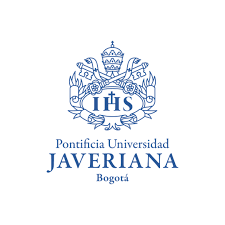
# **High Volume Data Processing**
### Workshop: **Data Classification with Performance Metrics**
Author: Daniel Felipe Castro Moreno

Start Date: 04/28/2026

Current Date: 05/25/2026

## Objective

Develop a supervised classification pipeline on the *Bank Marketing* dataset from the UCI repository, using Apache Spark (PySpark MLlib) as the distributed processing engine. The goal is to train, evaluate, and compare binary classification models capable of predicting whether a customer will subscribe to a term deposit (`y = yes/no`), applying performance metrics suitable for imbalanced datasets (AUC-ROC, F1-Score, Precision, and Recall).

## Methodology

1. **Spark Environment Setup:** An Apache Spark session is initialized for distributed processing of large data volumes.
2. **Dataset Loading and Initial Inspection:** `bank-full.csv` is loaded into a Spark DataFrame; schema, data types, and dimensions are reviewed.
3. **Data Type Casting:** Numeric columns read as `String` (CSV default) are cast to `Integer` to enable correct mathematical operations.
4. **Class Balance Analysis:** The distribution of the target variable `y` is examined to quantify class imbalance and define appropriate modeling strategies.
5. **Descriptive Statistical Analysis:** Summary statistics (mean, standard deviation, min, max) are calculated per column and globally, identifying ranges, dispersion, and potential anomalies.
6. **Exploratory Data Analysis (EDA):** Histograms for each numeric variable and comparative boxplots by class (`yes`/`no`) are generated to identify distributions, outliers, and discriminatory power of each variable.
7. **Data Preparation:** Outlier filtering, removal of the `pdays` column, and random oversampling of the minority class to address the 8.5:1 class imbalance.
8. **Feature Encoding and Vector Creation:** Categorical variables are encoded using `StringIndexer` + `OneHotEncoder`; all features are assembled into a single vector with `VectorAssembler` via a Spark ML `Pipeline`.
9. **Model Training:** Se entrenan cinco clasificadores binarios sobre el dataset balanceado y codificado: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (LinearSVC) y Gradient Boosting (GBTClassifier).
10. **Model Evaluation:** Each model is evaluated using Accuracy, Precision, Recall, F1-Score, and AUC-ROC. Confusion matrices and ROC curves are generated.
11. **Conclusions:** Results are summarized and the best model is selected based on the metrics most relevant for the imbalanced marketing classification problem.

## Data Dictionary

Source: [UCI Machine Learning Repository – Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)

The dataset records information from telephone marketing campaigns of a Portuguese bank between 2008 and 2013. Each record corresponds to a customer contacted during a campaign.

### Input Variables

| Variable    | Tipo        | Description |
|-------------|-------------|-------------|
| `age`       | Numeric    | Customer age (years) |
| `job`       | Categorical  | Job type (`admin.`, `technician`, `services`, `management`, `retired`, `blue-collar`, `unemployed`, `entrepreneur`, `housemaid`, `unknown`, `self-employed`, `student`) |
| `marital`   | Categorical  | Marital status (`married`, `single`, `divorced`) |
| `education` | Categorical  | Education level (`primary`, `secondary`, `tertiary`, `unknown`) |
| `default`   | Binary     | Has credit in default? (`yes`/`no`) |
| `balance`   | Numeric    | Average annual balance in checking account (euros). Can be negative |
| `housing`   | Binary     | Has a housing loan? (`yes`/`no`) |
| `loan`      | Binary     | Has a personal loan? (`yes`/`no`) |
| `contact`   | Categorical  | Contact communication type (`cellular`, `telephone`, `unknown`) |
| `day`       | Numeric    | Day of month of last contact (1–31) |
| `month`     | Categorical  | Month of last contact (`jan`–`dec`) |
| `duration`  | Numeric    | Duration of last contact in seconds |
| `campaign`  | Numeric    | Number of contacts performed during this campaign for this client |
| `pdays`     | Numeric    | Days since the client was last contacted from a previous campaign (−1 if never contacted) |
| `previous`  | Numeric    | Number of contacts performed before this campaign for this client |
| `poutcome`  | Categorical  | Outcome of the previous marketing campaign (`success`, `failure`, `other`, `unknown`) |

### Target Variable

| Variable | Tipo    | Description |
|----------|---------|-------------|
| `y`      | Binary | Has the client subscribed to a term deposit? (`yes`/`no`) |

## 1. Environment Setup

In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


The following libraries are installed and loaded for the pipeline:

- **NumPy / Pandas**: numerical and tabular manipulation on the *driver* node.
- **Matplotlib / Seaborn**: static data visualization.
- **PySpark**: distributed processing engine. The modules used are `sql` (DataFrames, SQL functions), `ml.feature` (variable encoding), `ml.evaluation` (classification metrics), and `ml` (ML Pipeline).
- **scikit-learn**: used only to compute the ROC curve with `roc_curve` and `auc`, since PySpark does not directly expose the curve's individual points.

In [2]:
# Import general libraries for numerical, tabular manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Specialized libraries
from pylab import *
import findspark
findspark.init('/Almacen/Spark')
from pyspark.sql import functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc

### Spark Session

Apache Spark is an in-memory distributed processing engine designed for large data volumes. Unlike Pandas, which operates on a single node, Spark distributes work across multiple cluster nodes, enabling scaling to terabytes of data.

- **`SparkConf`**: cluster configuration object (application name, assigned resources, etc.).
- **`SparkSession`**: single entry point for working with DataFrames, SQL, and MLlib in Spark 2.x+.
- **`SQLContext`**: enables running SQL queries directly on DataFrames registered as temporary tables.

In [3]:
configura = SparkConf() # config object
configura.setAppName("Classification_Castro")  # app name for Spark UI
sparkCastro = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext=sparkCastro.sparkContext, sparkSession=sparkCastro) # enables SQL on DataFrames
sparkContextoCastro = sparkCastro.sparkContext.getOrCreate()  # low-level SparkContext
print("Session created: sparkCastro")
sparkCastro

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/20 21:25:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Session created: sparkCastro


The session is successfully created under the name `Classification_Castro`. Spark launches its monitoring interface (*Spark UI*) on port 4040, where it is possible to inspect the jobs, stages, and tasks of each executed operation.

## 2. Dataset Loading and Initial Inspection

The `bank-full.csv` file is loaded into a Spark DataFrame. The separator used is a semicolon (`;`), a common convention in European-origin datasets. The `header=true` option indicates that the first row contains column names.

In [4]:
# Load the CSV file into a Spark DataFrame using ';' as separator (European convention)
dfPy00 = sparkCastro.read.format("csv").option("header","true").option("sep", ";").load("bank-full.csv")
dfPy00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

The first 5 rows show the dataset structure. All fields, including numeric ones, are loaded as `String` type (CSV default). Explicit casting is required before any mathematical or statistical operation. The column `y` contains `"yes"` and `"no"` as text and will be numerically encoded for modeling.

In [5]:
# Total record count to size the data volume to process
print(f"Total records: {dfPy00.count()}")

Total records: 45211


The dataset contains **45,211 records** with **17 columns** (16 input variables + 1 target variable). PySpark allows scaling this same pipeline to tens of millions of records without changing the code.

In [6]:
dfPy00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

The 17 columns correspond exactly to the variables described in the data dictionary. 8 numeric variables are identified that will be cast in the next step.

## 3. Data Type Transformation

The columns `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, and `previous` must be converted from `String` to `Integer`. The column `month` is excluded since it contains text values (`jan`, `feb`, ...) and will be treated as a categorical variable.

In [7]:
# List of columns to convert from String to Integer
# Note: 'month' is excluded because it is categorical (jan, feb, ...) and cannot be cast to integer
colInt = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
dfPy01 = dfPy00
for column in colInt:
    dfPy01 = dfPy01.withColumn(column, F.col(column).cast("integer"))
dfPy01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



The updated schema (`dfPy01`) confirms that the 7 numeric columns now have `integer` type. The `month` column remains as `string` and will be encoded with `StringIndexer` in the ML pipeline.

## 4. Class Balance Analysis

Before any modeling, the distribution of the target variable must be examined. An **imbalanced dataset** occurs when one class numerically dominates over others, potentially inducing the model to always predict the majority class with high apparent accuracy without learning the actual minority pattern.

**Imbalance handling techniques:**
- *Oversampling* of the minority class (e.g., SMOTE).
- Random *undersampling* of the majority class.
- Class weight adjustment (`classWeight`) in the training algorithm.
- Decision threshold adjustment (0.5 is not always optimal).

**Appropriate metrics for imbalanced classes:**
- **AUC-ROC**: area under the ROC curve; measures discriminatory capacity regardless of threshold.
- **Precision**: of those predicted as `yes`, how many actually are?
- **Recall (Sensitivity)**: of all actual `yes`, how many does the model detect?
- **F1-Score**: harmonic mean of Precision and Recall.
- **Simple accuracy is not a reliable metric** in this context.

In [8]:
# Calculate the distribution of target variable 'y' to quantify class imbalance
total = dfPy01.count()
df_Y = dfPy01.groupBy("y").count()
auxPD = df_Y.withColumn("Percentage", df_Y["count"]*100/total)
auxPD.show()

[Stage 8:>                                                          (0 + 2) / 2]

+---+-----+------------------+
|  y|count|        Percentage|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



| Class | Records | Percentage |
|-------|---------|------------|
| `no`  | 39,922  | ~88.3 %    |
| `yes` | 5,289   | ~11.7 %    |

The dataset presents **severe imbalance** with an approximate ratio of 8.5:1. Evaluation must use AUC-ROC and F1-Score rather than simple accuracy.

## 5. Descriptive Statistical Analysis

### 5.1 Statistics per Numeric Column

Each numeric column is iterated and its individual statistical summary is printed using `describe()`, allowing observation of count, mean, standard deviation, minimum, and maximum in isolation.

In [9]:
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

numeric_columns = [
    f.name for f in dfPy01.schema.fields
    if isinstance(f.dataType, (IntegerType, DoubleType, FloatType, LongType))
]

for col in numeric_columns:
    print(f"Statistical summary of column: {col}")
    dfPy01.describe([col]).show()

Statistical summary of column: age
+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|             45211|
|   mean| 40.93621021432837|
| stddev|10.618762040975401|
|    min|                18|
|    max|                95|
+-------+------------------+

Statistical summary of column: balance
+-------+------------------+
|summary|           balance|
+-------+------------------+
|  count|             45211|
|   mean|1362.2720576850766|
| stddev|3044.7658291685243|
|    min|             -8019|
|    max|            102127|
+-------+------------------+

Statistical summary of column: day
+-------+-----------------+
|summary|              day|
+-------+-----------------+
|  count|            45211|
|   mean|15.80641879188693|
| stddev|8.322476153044589|
|    min|                1|
|    max|               31|
+-------+-----------------+

Statistical summary of column: duration
+-------+-----------------+
|summary|         duration|
+-------+---------

Key findings from the column-by-column analysis:

- **`age`**: range 18–95 years, mean ~41 years. Customers over 70 suggest a retired segment with different behavior.
- **`balance`**: can be negative (overdrawn customers). High standard deviation (~3,044 €) vs mean (~1,362 €) indicates a very right-skewed distribution with high-value outliers.
- **`duration`**: mean ~258 s and standard deviation ~257 s. When mean and SD are similar, the distribution is likely exponential or heavily right-skewed.
- **`campaign`**: mean ~2.76 contacts with maximum 63. Most customers were contacted very few times.
- **`pdays`**: mean ~40 days with minimum −1. The value −1 is a sentinel code indicating no prior contact; this variable mixes two types of information.
- **`previous`**: mean ~0.58 with maximum 275. Highly concentrated at 0 (no prior contact history).

### 5.2 Global Dataset Statistics

`describe().toPandas()` generates a summary of all columns simultaneously. **Note:** `toPandas()` brings all data to the driver node; use only with small DataFrames.

In [10]:
dfPy01.describe().toPandas()

26/05/20 21:25:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


The global table allows contrasting all variables at once. Notable findings:
- `job` shows `"management"` as most frequent; `"unknown"` indicates implicit missing data.
- `contact` has a significant portion of `"unknown"` channel records, limiting its informative power.
- `poutcome` has many `"unknown"` values, coinciding with customers whose `previous = 0`.
- `duration = 0` indicates the call was never made; these records always have `y = "no"` and should be filtered before modeling.

## 6. Exploratory Data Analysis (EDA)

### 6.1 Histograms of Numeric Variables

A **histogram** divides the value range into equal-width bins and counts how many records fall into each, allowing identification of distribution shape, modality, and unusual concentrations. The 8 numeric variables are plotted with 20 bins each.

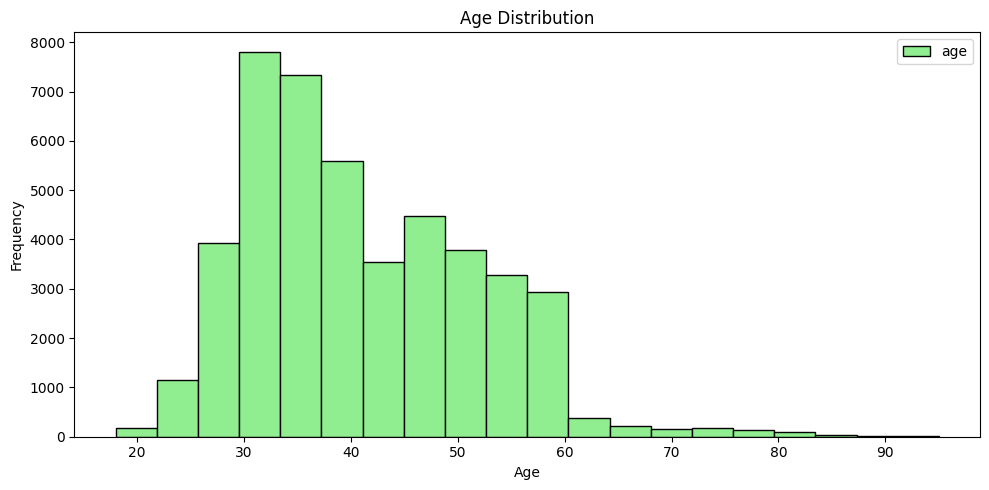

In [11]:
histogram = dfPy01.select('age').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightgreen', figsize=(10, 5))
plt.ylabel('Frequency')
plt.xlabel('Age')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

**`age` — Age Distribution**

Approximately normal with slight right skew. Highest concentration between 25–55 years, peak around 32–38 years. Right tail toward 75–95 years corresponds to retired customers who may have different savings behavior.

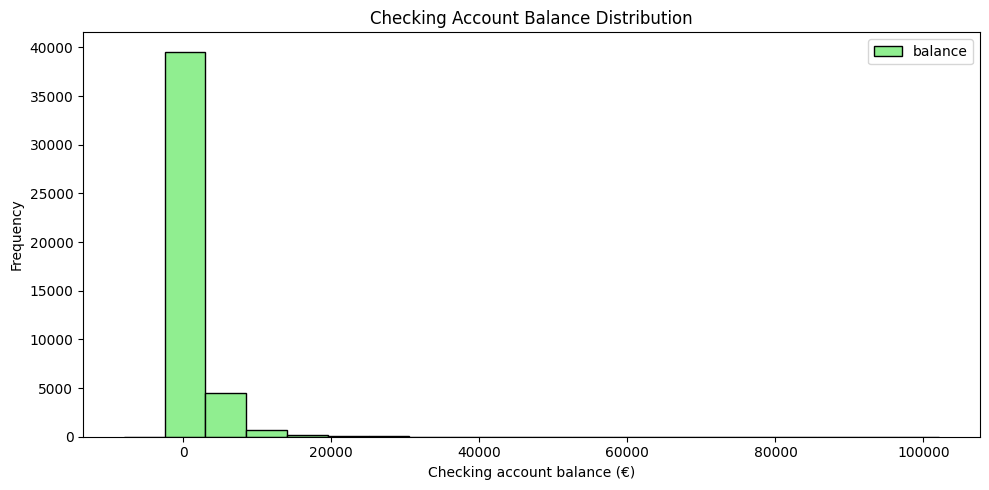

In [12]:
histogram = dfPy01.select('balance').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightgreen', figsize=(10, 5))
plt.ylabel('Frequency')
plt.xlabel('Checking account balance (€)')
plt.title('Checking Account Balance Distribution')
plt.tight_layout()
plt.show()

**`balance` — Checking Account Balance Distribution**

Strongly right-skewed. Most customers have balances between −1,000 € and 5,000 €, while a minority reaches values above 20,000 €. Negative balances indicate overdrawn customers. A `log(x + c)` transformation is recommended for scale-sensitive models.

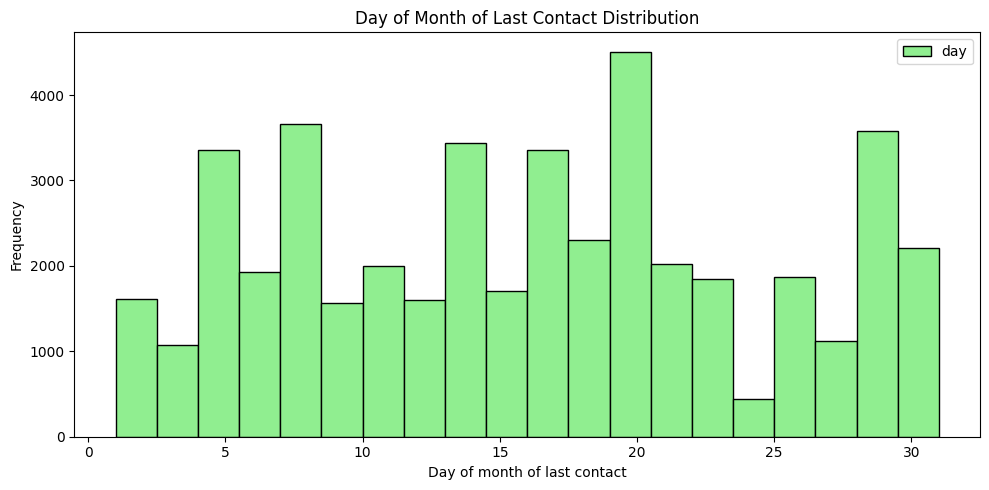

In [13]:
histogram = dfPy01.select('day').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightgreen', figsize=(10, 5))
plt.ylabel('Frequency')
plt.xlabel('Day of month of last contact')
plt.title('Day of Month of Last Contact Distribution')
plt.tight_layout()
plt.show()

**`day` — Day of Month Distribution**

Relatively uniform between days 1–31 with slight peaks around mid-month. Low predictive power on its own; may be more useful combined with month.

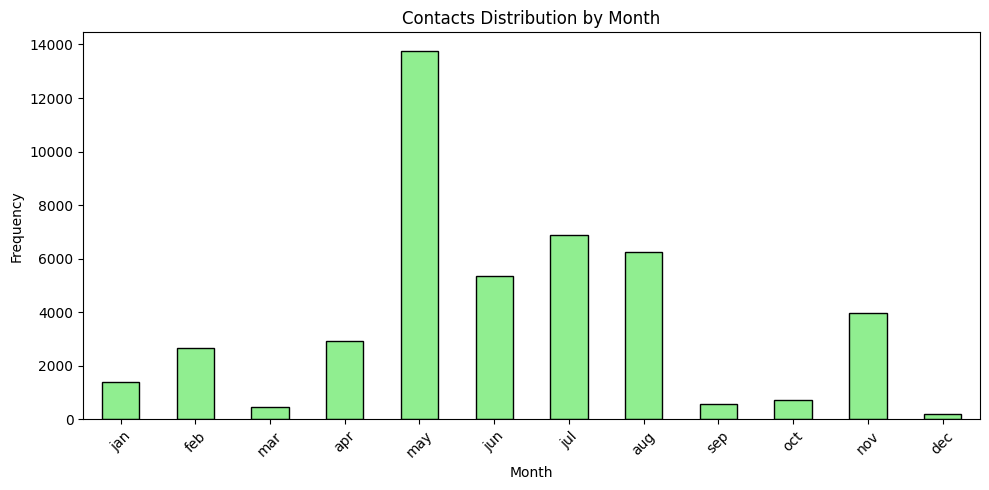

In [14]:
# month is categorical → plotted as bar chart ordered by month
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_pd = dfPy01.select('month').toPandas()
month_counts = month_pd['month'].value_counts().reindex(month_order).fillna(0)

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', edgecolor='black', color='lightgreen')
plt.ylabel('Frequency')
plt.xlabel('Month')
plt.title('Contacts Distribution by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**`month` — Contacts Distribution by Month**

Non-uniform: May, July, and August concentrate over 50% of campaign interactions. December and March record the lowest contact volume. Higher contact volume does not imply higher conversion rate.

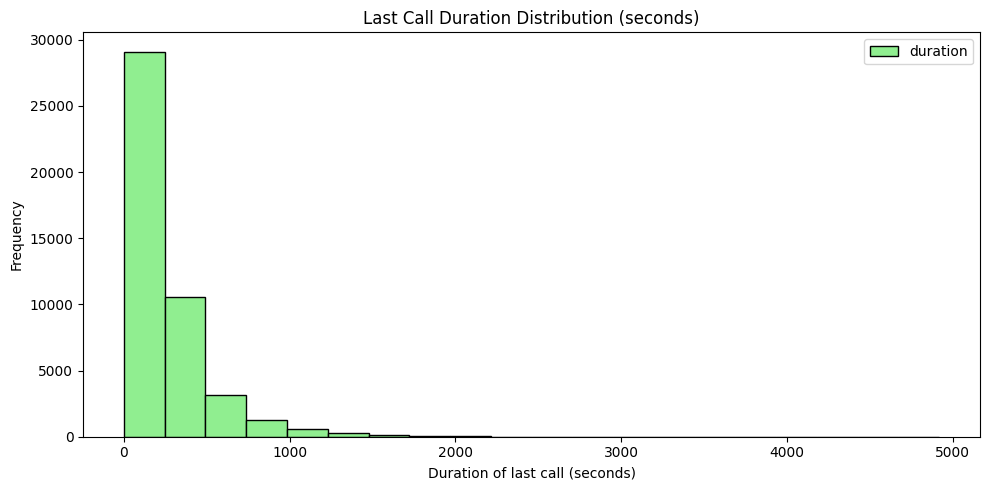

In [15]:
histogram = dfPy01.select('duration').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightgreen', figsize=(10, 5))
plt.ylabel('Frequency')
plt.xlabel('Duration of last call (seconds)')
plt.title('Last Call Duration Distribution (seconds)')
plt.tight_layout()
plt.show()

**`duration` — Last Call Duration Distribution**

Exponential / heavily right-skewed. Most calls are under 500 s, with a peak at 0–200 s. Highest discriminatory power in the dataset, but constitutes **data leakage** since duration is not known before the call. Should be excluded from pre-contact prediction models.

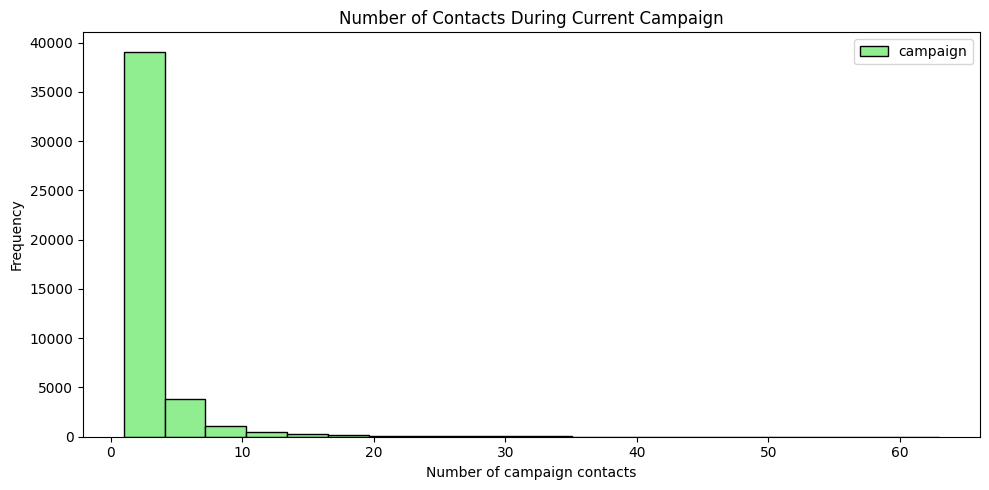

In [16]:
histogram = dfPy01.select('campaign').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightgreen', figsize=(10, 5))
plt.ylabel('Frequency')
plt.xlabel('Number of campaign contacts')
plt.title('Number of Contacts During Current Campaign')
plt.tight_layout()
plt.show()

**`campaign` — Number of Contacts During Current Campaign**

Heavily right-skewed. Most customers were contacted 1–5 times (peak at 1–2). Extreme values (> 20 contacts) are very rare. More contact attempts negatively correlate with conversion.

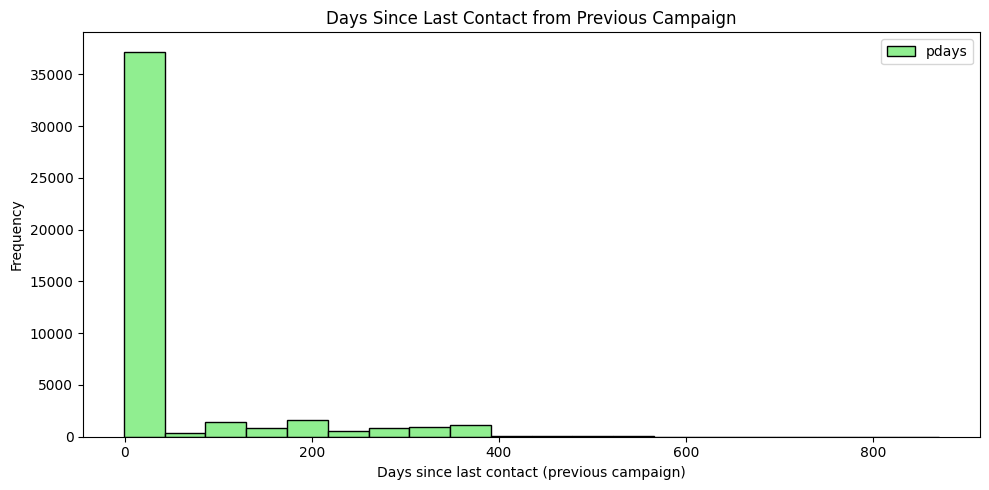

In [17]:
histogram = dfPy01.select('pdays').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightgreen', figsize=(10, 5))
plt.ylabel('Frequency')
plt.xlabel('Days since last contact (previous campaign)')
plt.title('Days Since Last Contact from Previous Campaign')
plt.tight_layout()
plt.show()

**`pdays` — Days Since Last Contact from Previous Campaign**

Bimodal: a huge spike at −1 (customers never previously contacted) and a dispersed distribution between 1–871 days. The sentinel value −1 mixes two types of information. Recommended to create derived features: `was_previously_contacted` (0/1) and `days_since_last_contact`.

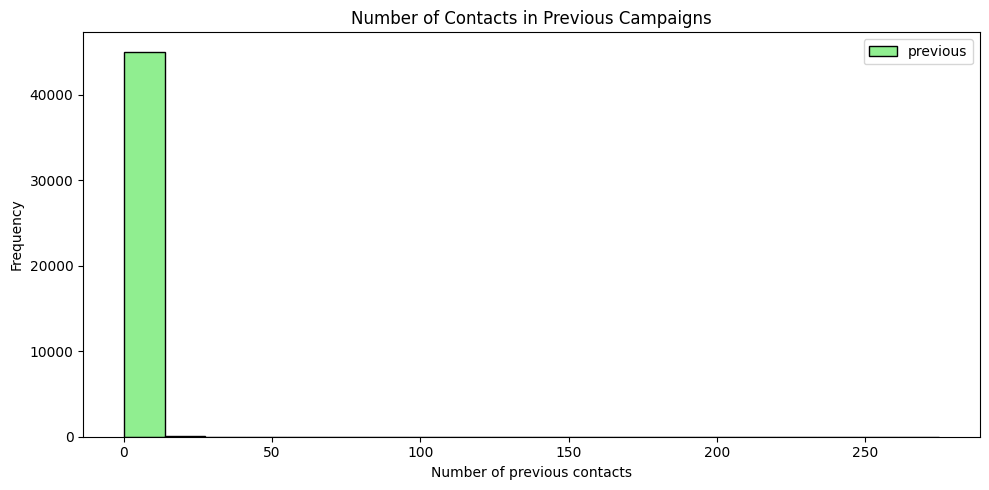

In [18]:
histogram = dfPy01.select('previous').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightgreen', figsize=(10, 5))
plt.ylabel('Frequency')
plt.xlabel('Number of previous contacts')
plt.title('Number of Contacts in Previous Campaigns')
plt.tight_layout()
plt.show()

**`previous` — Number of Contacts in Previous Campaigns**

Extremely concentrated at 0 (no prior contact). Despite this, customers with at least one prior successful contact are marginally more likely to accept the current offer. Combined with `poutcome`, can capture the customer history effect.

### 6.2 Comparative Boxplots by Class (target variable `y`)

A **boxplot** summarizes a numeric variable's distribution in five statistics: median (Q2), IQR (Q1–Q3), whiskers (1.5×IQR), and outlier points. Comparing boxplots between `yes` and `no` customers reveals the **discriminatory power** of each variable: little overlap → good separator; complete overlap → little contribution to the model.

In [19]:
df_pd = dfPy01.toPandas()

Converting to Pandas (`toPandas()`) brings all data to the driver node. With 45,211 records and few numeric columns, memory consumption is manageable (~50 MB).

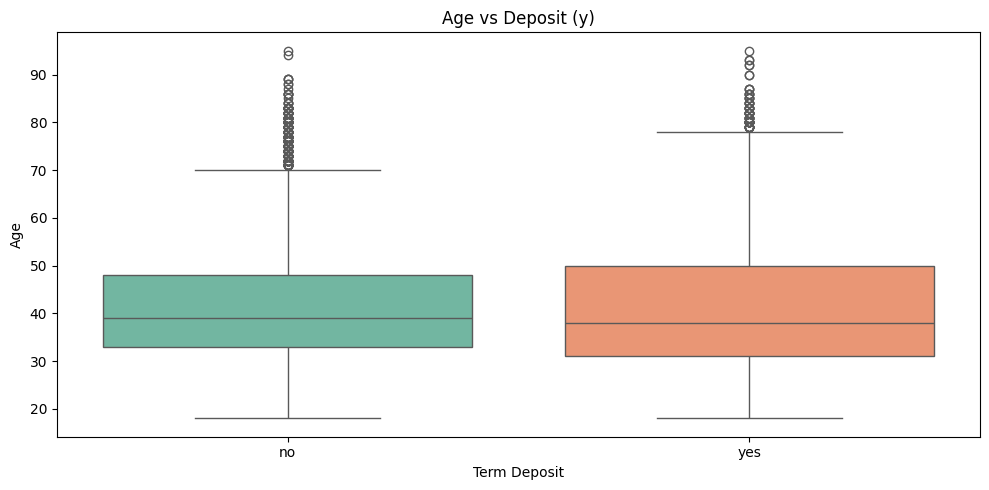

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='age', data=df_pd, hue='y', palette='Set2', legend=False)
plt.title('Age vs Deposit (y)')
plt.xlabel('Term Deposit')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

**`age` vs Deposit** — Distributions are very similar between `yes` and `no` groups (medians ~39–41 years, overlapping IQRs). Age alone is not a strong discriminator, though useful in combination with `balance` and `education` in tree-based models.

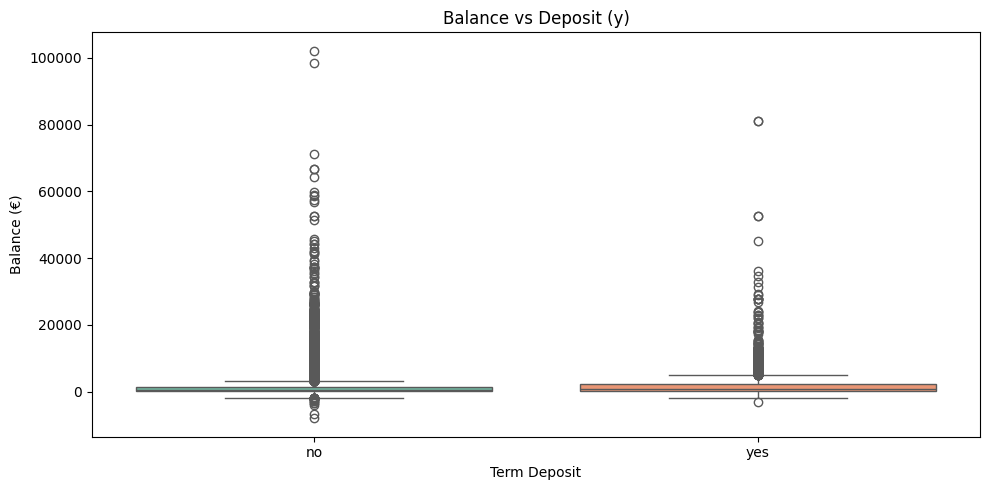

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='balance', data=df_pd, hue='y', palette='Set2', legend=False)
plt.title('Balance vs Deposit (y)')
plt.xlabel('Term Deposit')
plt.ylabel('Balance (€)')
plt.tight_layout()
plt.show()

**`balance` vs Deposit** — Customers who subscribed (`yes`) show a visibly higher balance median. Greater available balance facilitates the decision to commit funds to a term deposit. **Moderate discriminatory power** — should be included in all models.

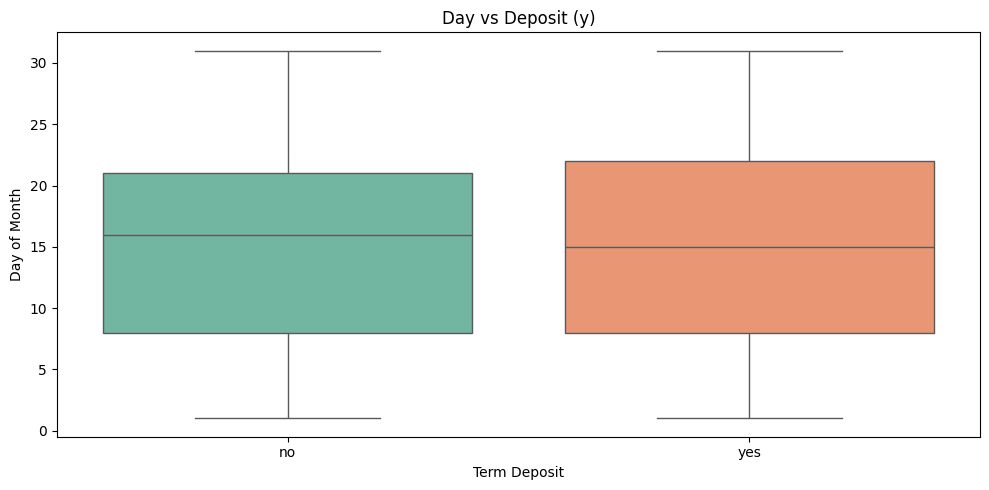

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='day', data=df_pd, hue='y', palette='Set2', legend=False)
plt.title('Day vs Deposit (y)')
plt.xlabel('Term Deposit')
plt.ylabel('Day of Month')
plt.tight_layout()
plt.show()

**`day` vs Deposit** — Boxes of both classes are practically identical (same median ~16, same IQR). Day of the month **does not discriminate** between acceptors and rejectors.

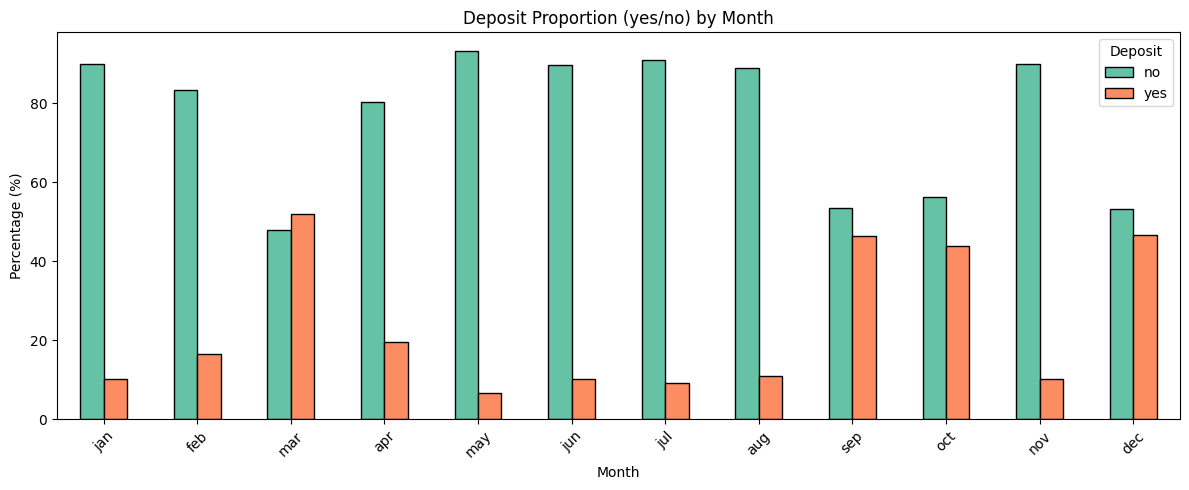

In [23]:
# month is categorical → deposit proportion (yes/no) by month
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_y = df_pd.groupby(['month','y']).size().unstack(fill_value=0)
month_y = month_y.reindex(month_order).fillna(0)
month_y_pct = month_y.div(month_y.sum(axis=1), axis=0) * 100

month_y_pct.plot(kind='bar', figsize=(12, 5), color=['#66c2a5','#fc8d62'], edgecolor='black')
plt.title('Deposit Proportion (yes/no) by Month')
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Deposit')
plt.tight_layout()
plt.show()

**`month` — Deposit Proportion by Month** — March, December, and September have the highest conversion rates despite low total contacts (more selective campaigns). May has the highest contact volume but one of the lowest conversion rates.

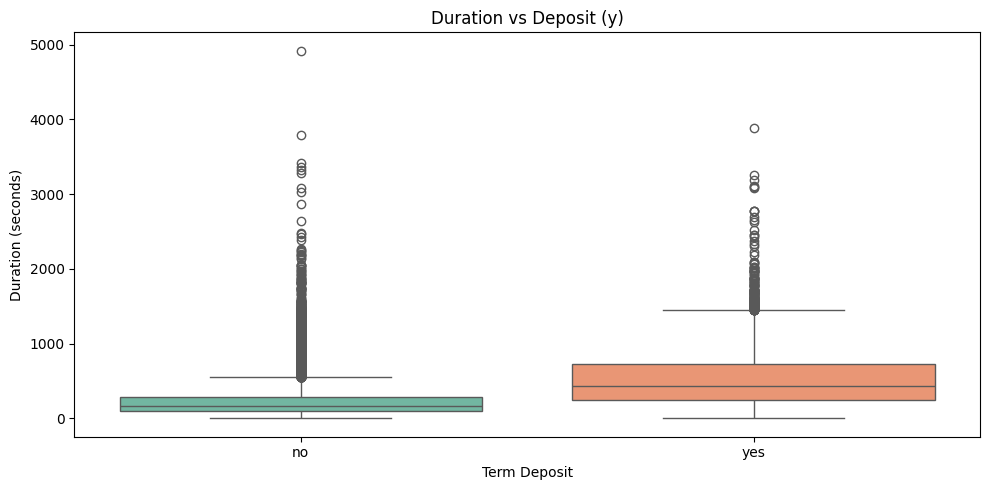

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='duration', data=df_pd, hue='y', palette='Set2', legend=False)
plt.title('Duration vs Deposit (y)')
plt.xlabel('Term Deposit')
plt.ylabel('Duration (seconds)')
plt.tight_layout()
plt.show()

**`duration` vs Deposit** — Most marked difference: `yes` customers had substantially longer calls (median ~535 s) vs `no` (median ~160 s). The most predictive variable, but constitutes **data leakage** since duration is only known after the call.

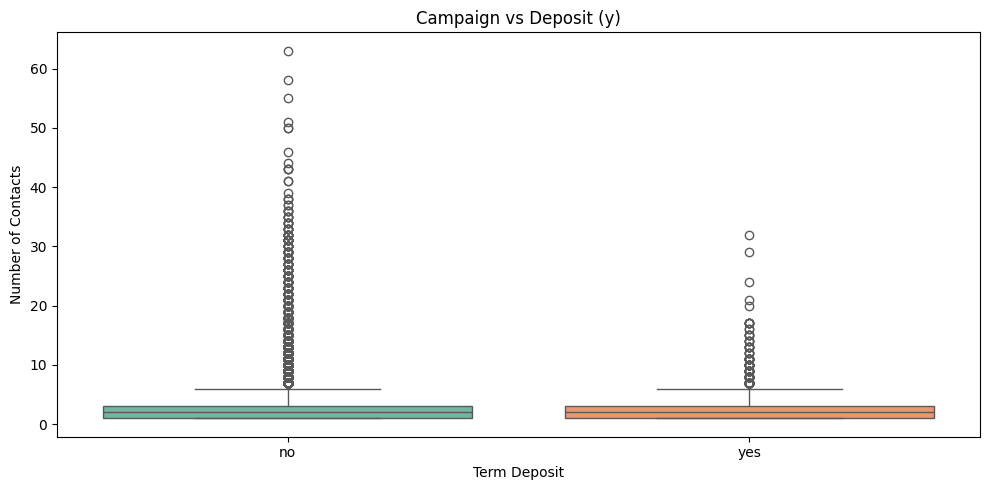

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='campaign', data=df_pd, hue='y', palette='Set2', legend=False)
plt.title('Campaign vs Deposit (y)')
plt.xlabel('Term Deposit')
plt.ylabel('Number of Contacts')
plt.tight_layout()
plt.show()

**`campaign` vs Deposit** — Customers who subscribed were contacted **fewer times** (median ~1 vs ~2). Outliers with many contacts (>10) belong almost exclusively to the `no` group: more attempts do not improve conversion.

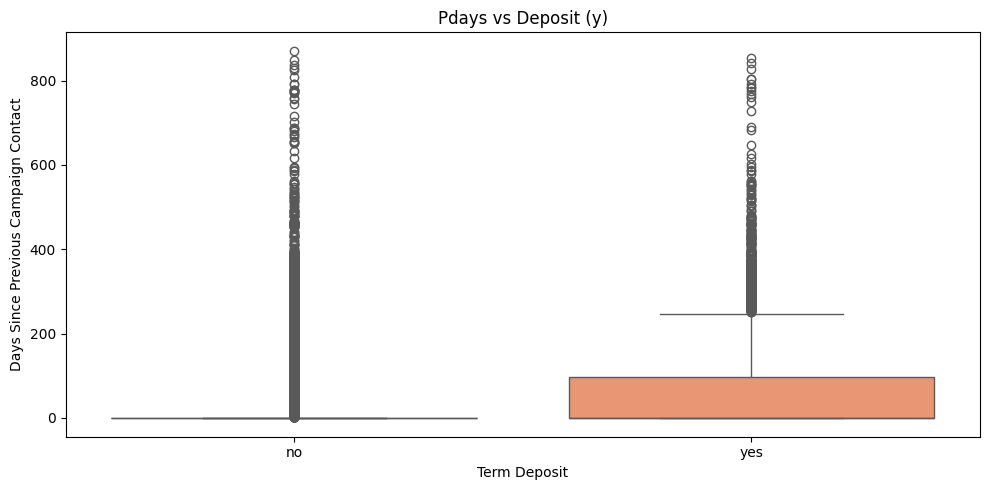

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='pdays', data=df_pd, hue='y', palette='Set2', legend=False)
plt.title('Pdays vs Deposit (y)')
plt.xlabel('Term Deposit')
plt.ylabel('Days Since Previous Campaign Contact')
plt.tight_layout()
plt.show()

**`pdays` vs Deposit** — The dominant presence of −1 in both classes makes boxes nearly identical. Among customers with prior contact (pdays ≥ 0), the `yes` group tends to have been contacted more recently.

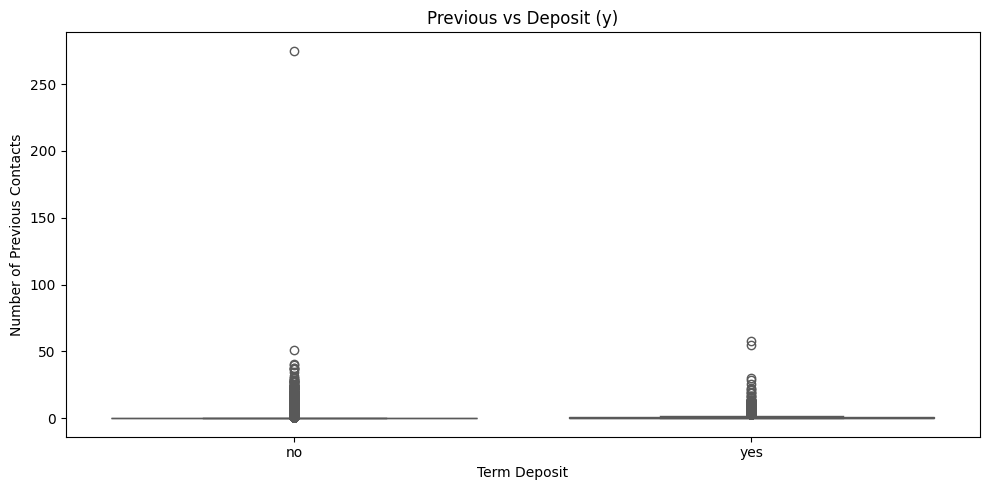

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='previous', data=df_pd, hue='y', palette='Set2', legend=False)
plt.title('Previous vs Deposit (y)')
plt.xlabel('Term Deposit')
plt.ylabel('Number of Previous Contacts')
plt.tight_layout()
plt.show()

**`previous` vs Deposit** — Both distributions are highly concentrated at 0. The `yes` group has a slightly higher median and Q3, indicating customers with prior interaction history are marginally more likely to subscribe.

- A DataFrame with only numeric columns is required
- The target variable `y` must be converted to binary (1=yes, 0=no)

In [28]:
# Select numeric columns for auxiliary correlation analysis subset
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Encode target variable 'y' as binary (1=yes, 0=no) for Pearson correlation calculation
dfAuxNum = dfPy01.select(colNum + ['y'])
dfAuxNum = dfAuxNum.withColumn('y', F.when(dfAuxNum['y'] == 'yes', 1).otherwise(0))
dfAuxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [29]:
# Assemble all numeric columns (including 'y') into a single feature vector required by MLlib API
ensamblador = VectorAssembler(inputCols = dfAuxNum.columns, outputCol = 'features')

# Apply assembler and keep only 'features' column for correlation calculation
dfNumVector = ensamblador.transform(dfAuxNum).select('features')

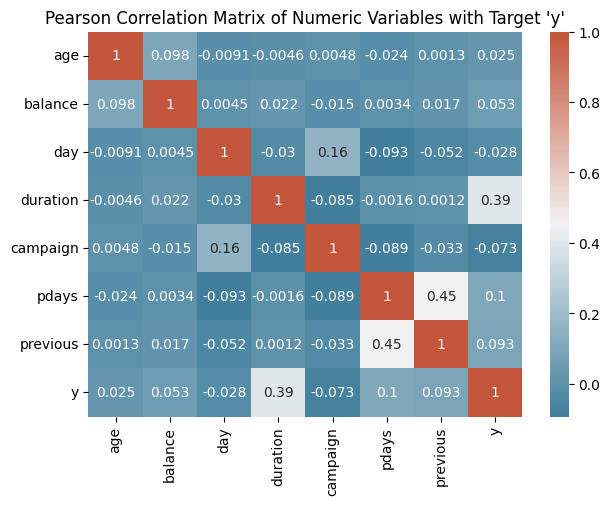

In [30]:
# Calculate Pearson correlation matrix using Spark MLlib's distributed API
matrizCorr = Correlation.corr(dfNumVector, 'features').head()

# Convert Spark result (DenseMatrix) to NumPy array for use with Pandas and Seaborn
vectorCorr = matrizCorr[0].toArray()

# Build Pandas DataFrame with the correlation matrix
dfCorr = pd.DataFrame(vectorCorr, columns = dfAuxNum.columns, index = dfAuxNum.columns)

plt.figure(figsize = (7, 5))
sns.heatmap(dfCorr, annot = True, cmap = sns.diverging_palette(230, 20, as_cmap = True))
plt.title("Pearson Correlation Matrix of Numeric Variables with Target 'y'")
plt.show()

`duration` has the highest correlation with `y` (r ≈ 0.40) confirming it should be excluded due to data leakage. `previous` and `pdays` show the next highest correlations. Overall, **weak linear correlations** suggest non-linear relationships (trees, Random Forest) may be more appropriate. The correlation between `previous` and `pdays` (r ≈ 0.45) indicates multicollinearity; both describe prior contact history.

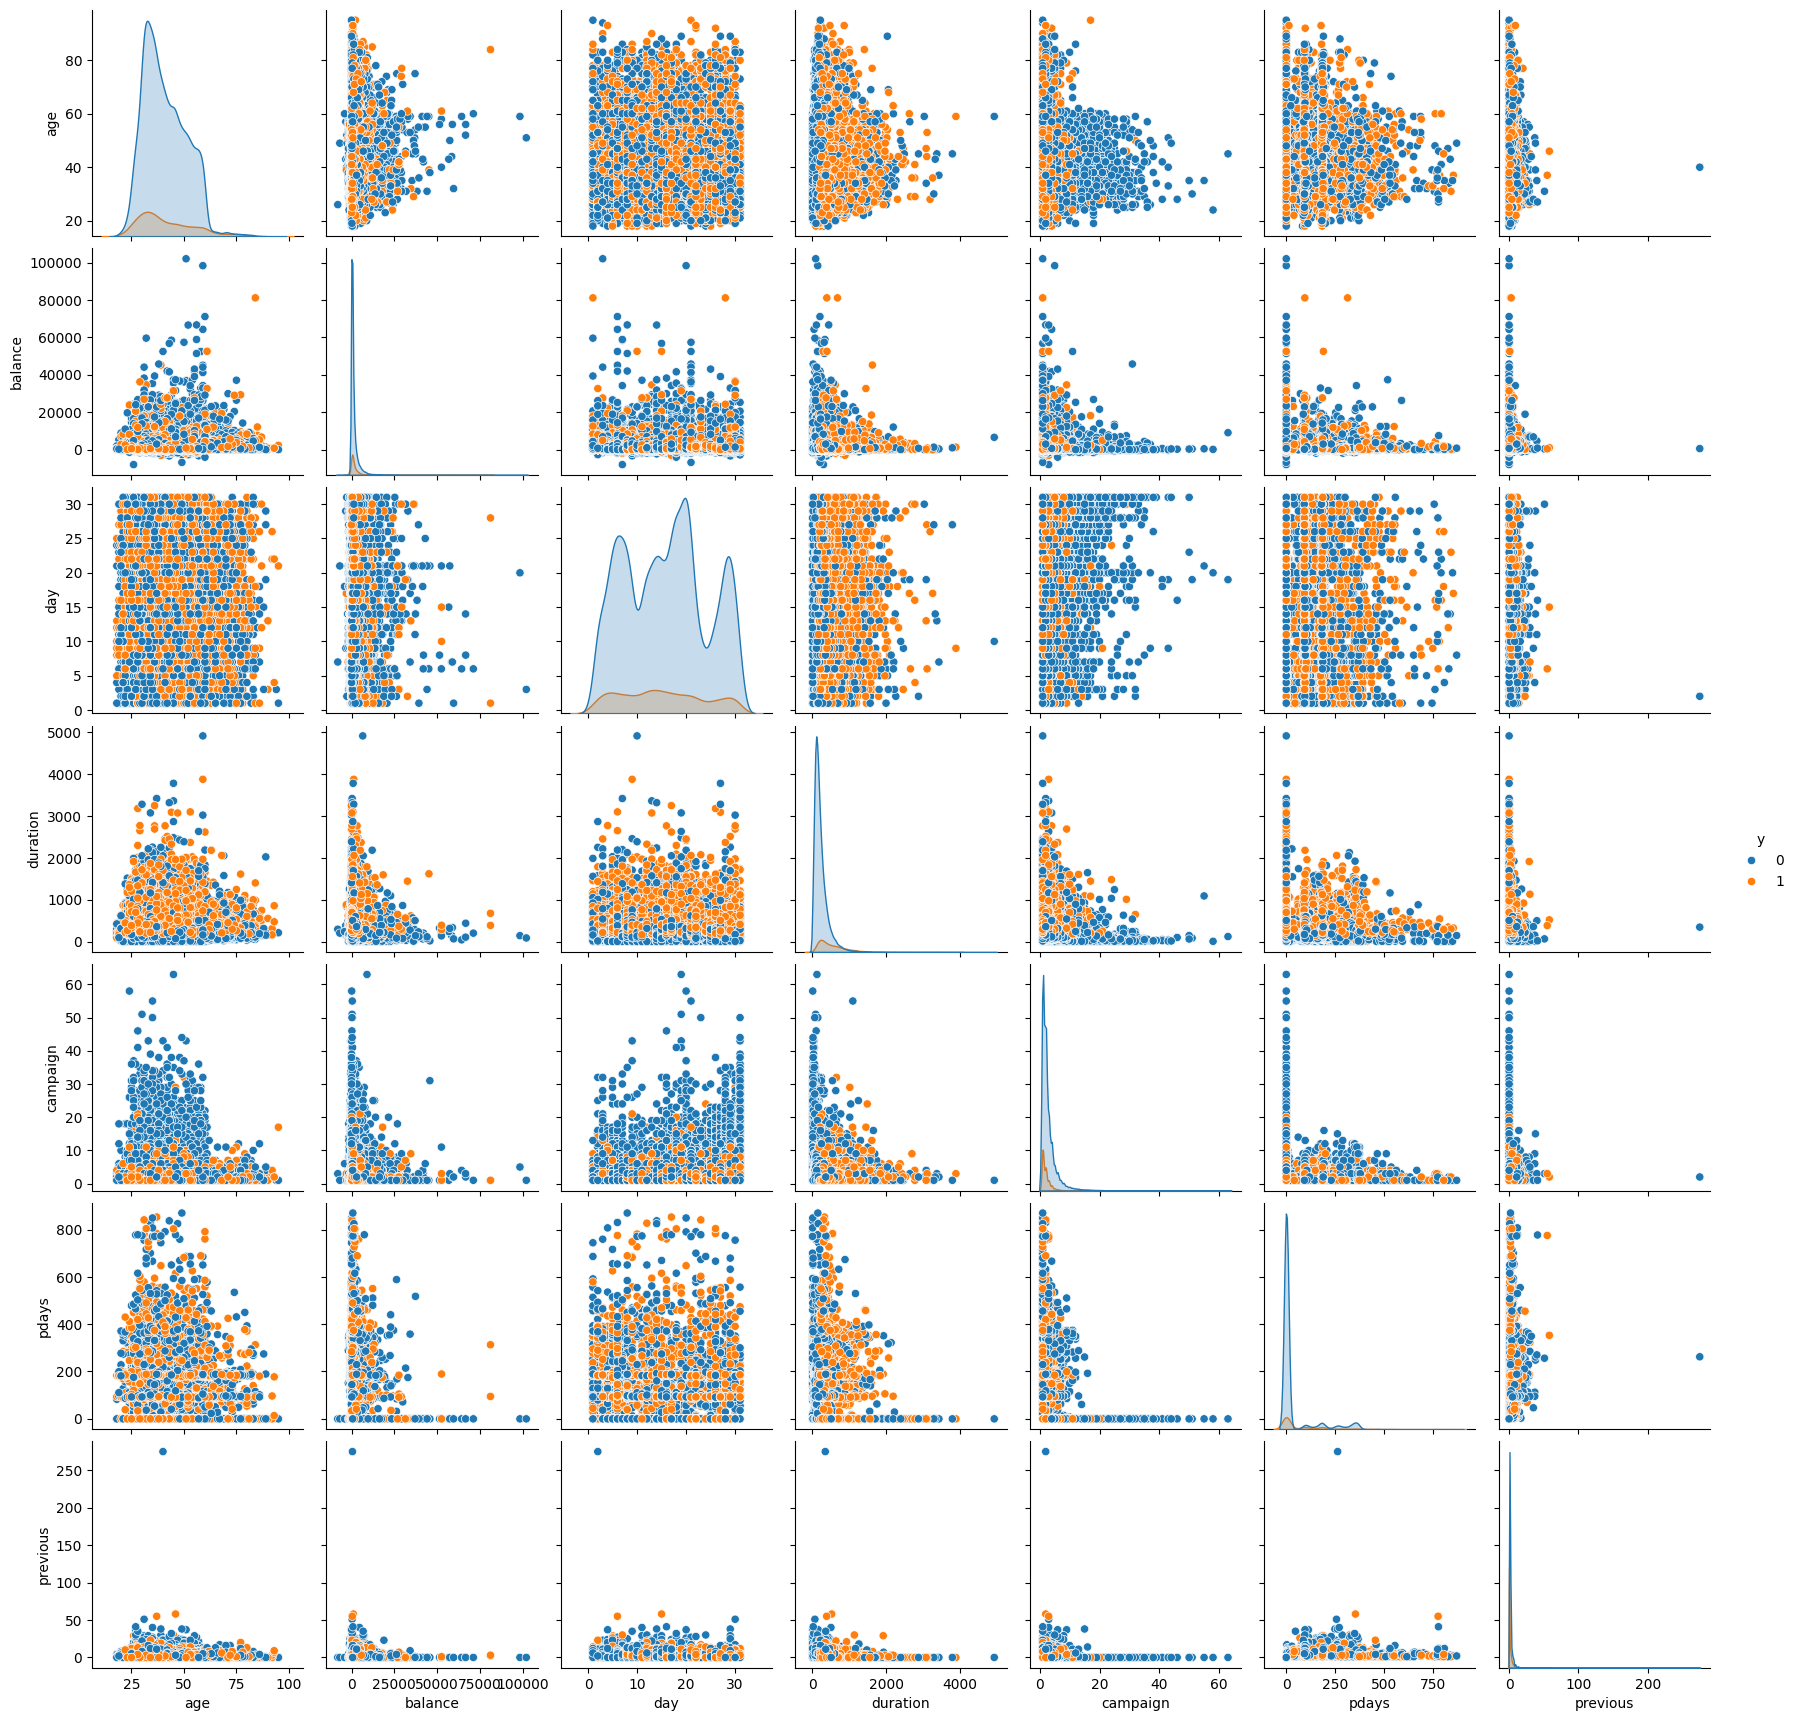

In [31]:
# Pairplot: scatter plot matrix to visualize bivariate relationships between all numeric variables, colored by class 'y'
sns.pairplot(dfAuxNum.toPandas(), kind = 'scatter', hue = 'y')
plt.show()

### Pie Charts
The following binary variables are analyzed:
- Default
- Housing
- Loan

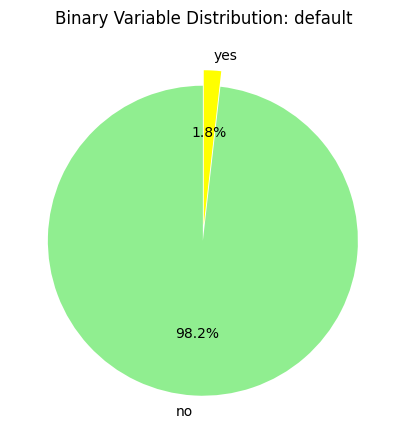

In [32]:
# Distribution of binary variable 'default' via pie chart
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']

plt.figure(figsize=(5,6))
cantBin = dfPy01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(
    kind = 'pie', explode = explode, colors = colors, autopct = '%1.1f%%', startangle = 90)
plt.title('Binary Variable Distribution: default')
plt.ylabel('')
plt.show()

Only **1.8%** of customers have credit in default, indicating strong payment punctuality. This extreme imbalance means `default` has very low discriminatory power on its own.

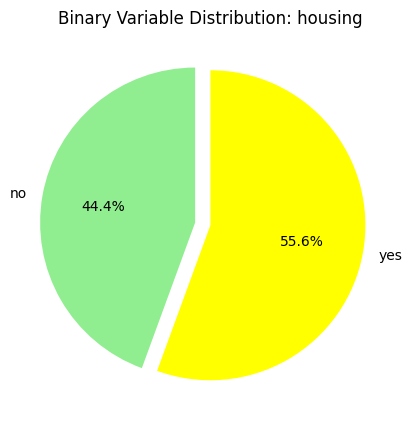

In [33]:
# Distribution of binary variable 'housing' via pie chart
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']

plt.figure(figsize=(5,6))
cantBin = dfPy01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(
    kind = 'pie', explode = explode, colors = colors, autopct = '%1.1f%%', startangle = 90)
plt.title('Binary Variable Distribution: housing')
plt.ylabel('')
plt.show()

More than half (55.6%) of customers have a housing loan. Customers with a mortgage tend to show lower conversion rates, as mortgage payments reduce available liquidity.

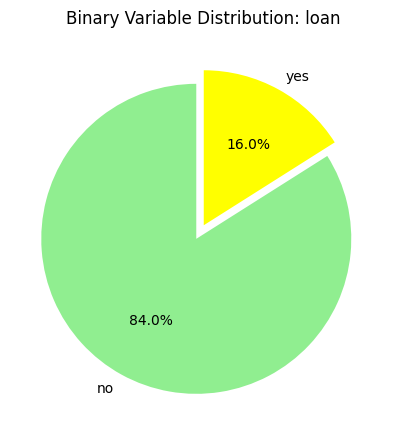

In [34]:
# Distribution of binary variable 'loan' via pie chart
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']

plt.figure(figsize=(5,6))
cantBin = dfPy01.groupBy('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(
    kind = 'pie', explode = explode, colors = colors, autopct = '%1.1f%%', startangle = 90)
plt.title('Binary Variable Distribution: loan')
plt.ylabel('')
plt.show()

Only **16.0%** of customers have a personal loan. Customers without additional personal debts may have greater liquidity available to commit to a term deposit. The combination of `housing = yes` and `loan = yes` could be a strong predictor of `y = no`.

# Multi-dimensional Categorical Variables

<Figure size 800x600 with 0 Axes>

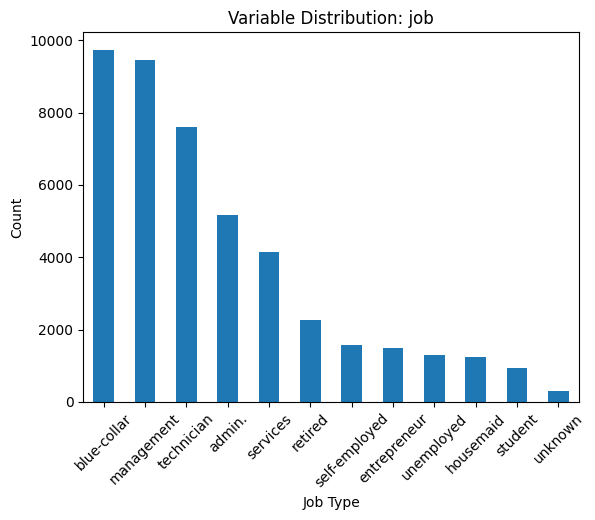

In [35]:
# Group by 'job' and sort descending by frequency
cantMulti = dfPy01.groupBy('job').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending = False)
plt.figure(figsize = (8, 6))
cantMulti.plot(kind = 'bar', x= 'job', y = 'count', legend = None)
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.title('Variable Distribution: job')
plt.xticks(rotation = 45)
plt.show()

**`job`** — `blue-collar` (~21%), `management` (~21%), and `technician` (~17%) together concentrate ~60% of records. `student` and `retired` tend to show above-average conversion rates despite lower volumes. Must be encoded with `StringIndexer` + `OneHotEncoder`.

<Figure size 800x600 with 0 Axes>

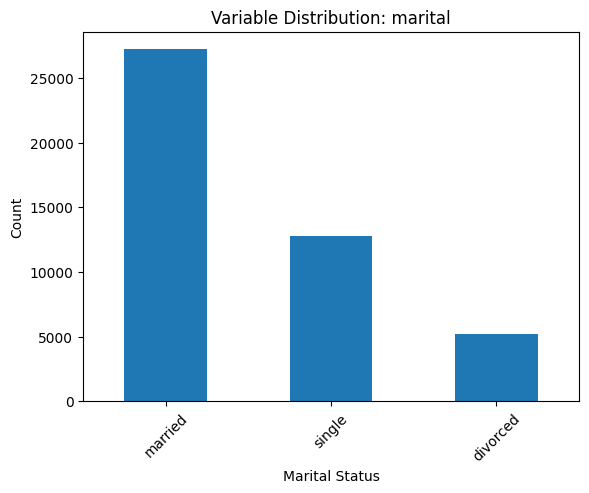

In [36]:
# Group by 'marital' and sort descending by frequency
cantMulti = dfPy01.groupBy('marital').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending = False)
plt.figure(figsize = (8, 6))
cantMulti.plot(kind = 'bar', x= 'marital', y = 'count', legend = None)
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.title('Variable Distribution: marital')
plt.xticks(rotation = 45)
plt.show()

**`marital`** — Majority married (~60%), single (~29%), divorced (~11%). Single customers show higher relative conversion rates due to greater financial flexibility.

<Figure size 800x600 with 0 Axes>

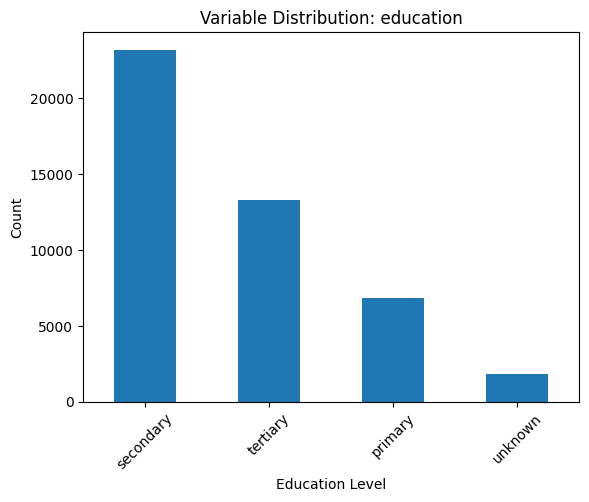

In [37]:
# Group by 'education' and sort descending by frequency
cantMulti = dfPy01.groupBy('education').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending = False)
plt.figure(figsize = (8, 6))
cantMulti.plot(kind = 'bar', x= 'education', y = 'count', legend = None)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Variable Distribution: education')
plt.xticks(rotation = 45)
plt.show()

**`education`** — `secondary` (~51%), `tertiary` (~30%), `primary` (~15%), `unknown` (~4%). Tertiary-educated customers have the highest conversion rate, consistent with greater financial literacy.

<Figure size 800x600 with 0 Axes>

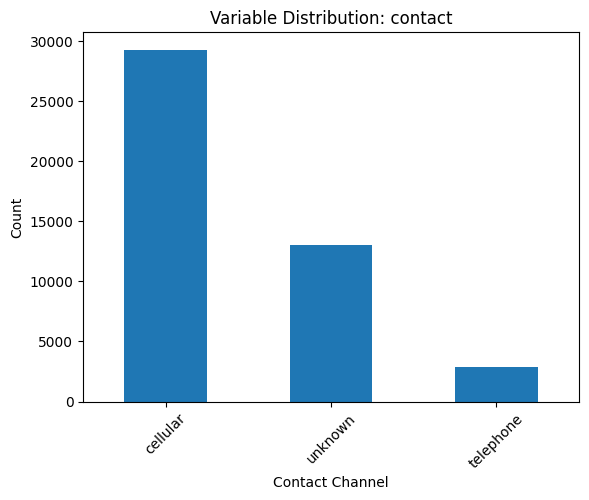

In [38]:
# Group by 'contact' and sort descending by frequency
cantMulti = dfPy01.groupBy('contact').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending = False)
plt.figure(figsize = (8, 6))
cantMulti.plot(kind = 'bar', x= 'contact', y = 'count', legend = None)
plt.xlabel('Contact Channel')
plt.ylabel('Count')
plt.title('Variable Distribution: contact')
plt.xticks(rotation = 45)
plt.show()

**`contact`** — `cellular` (~64%), `unknown` (~29%), `telephone` (~7%). Cellular contact has higher conversion rates; `unknown` channel shows the lowest rates.

<Figure size 800x600 with 0 Axes>

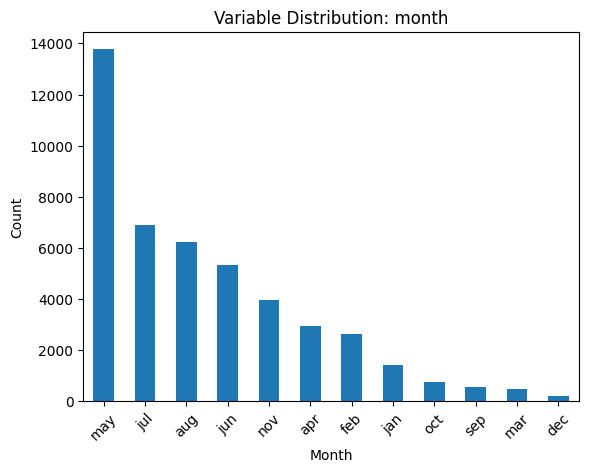

In [39]:
# Group by 'month' and sort descending by frequency
cantMulti = dfPy01.groupBy('month').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending = False)
plt.figure(figsize = (8, 6))
cantMulti.plot(kind = 'bar', x= 'month', y = 'count', legend = None)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Variable Distribution: month')
plt.xticks(rotation = 45)
plt.show()

**`month`** — May (~30%), July (~17%), August (~15%) concentrate over 60% of activity. Autumn months have the highest conversion rates despite low contact volumes, suggesting more selective campaigns.

<Figure size 800x600 with 0 Axes>

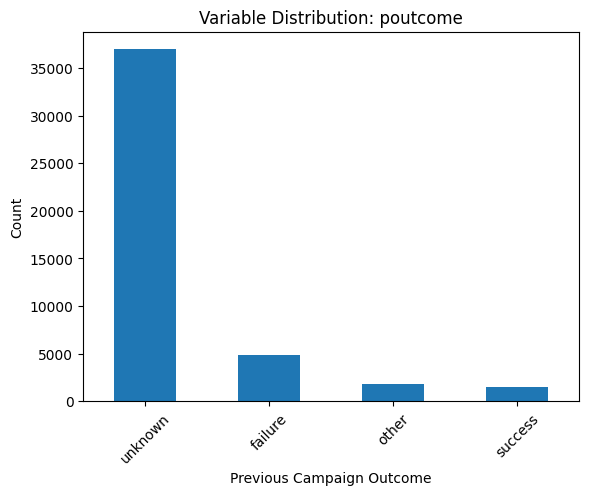

In [40]:
# Group by 'poutcome' and sort descending by frequency
cantMulti = dfPy01.groupBy('poutcome').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending = False)
plt.figure(figsize = (8, 6))
cantMulti.plot(kind = 'bar', x= 'poutcome', y = 'count', legend = None)
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Count')
plt.title('Variable Distribution: poutcome')
plt.xticks(rotation = 45)
plt.show()

**`poutcome`** — ~82% `unknown` (no prior campaign history). Among those with history, `success` (~3%) has 3–4× higher conversion than the overall average — the strongest signal in the dataset for customers with prior history.

# Grouped Bar Charts by Categorical Variables vs Target Variable `y` (term deposit)

### `job` vs Deposit (`y`)

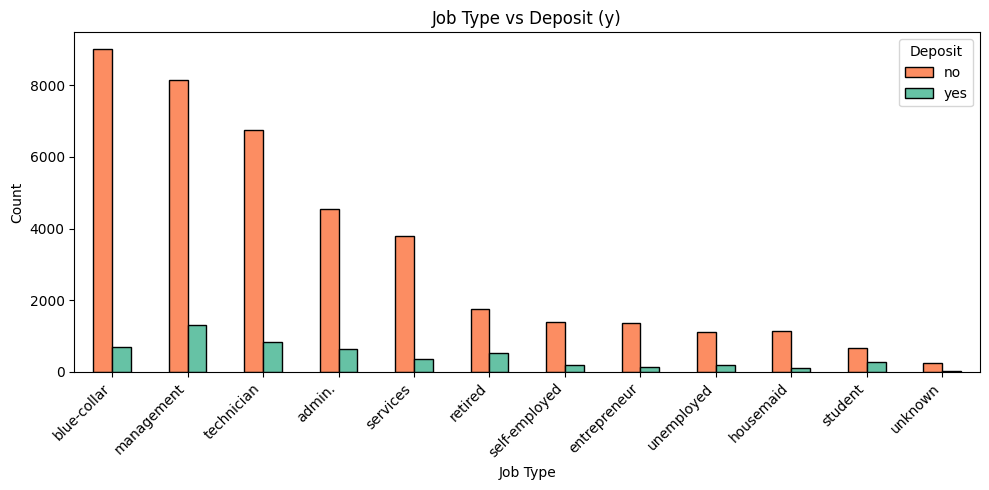

In [41]:
# Grouped bar chart: job vs y
crata_job = dfPy01.crosstab('job', 'y').toPandas()
crata_job = crata_job.set_index('job_y')
crata_job = crata_job.loc[crata_job.sum(axis=1).sort_values(ascending=False).index]
ax = crata_job.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Job Type')
ax.set_ylabel('Count')
ax.set_title('Job Type vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`student` and `retired` have the highest relative conversion rates. `blue-collar` and `services` have the lowest. `management` dominates in volume with moderate conversion.

### `marital` vs Deposit (`y`)

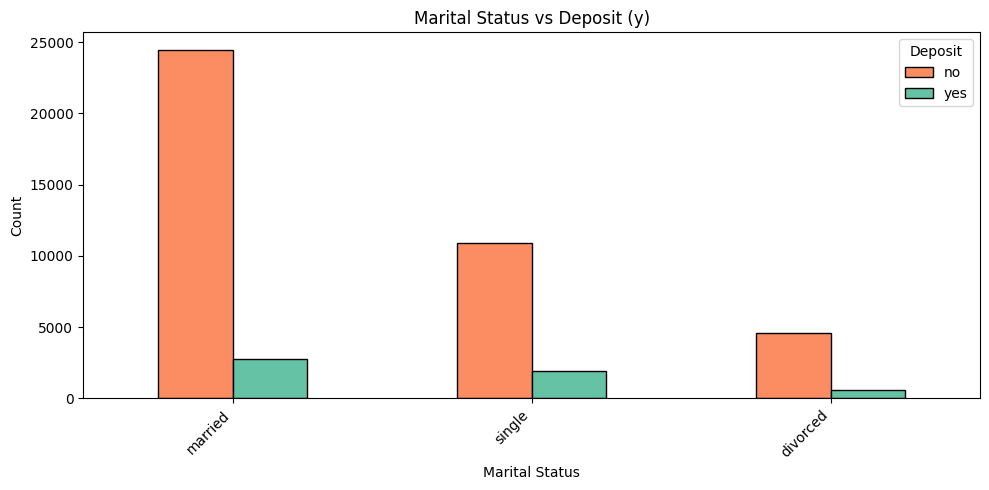

In [42]:
# Grouped bar chart: marital vs y
crata_marital = dfPy01.crosstab('marital', 'y').toPandas()
crata_marital = crata_marital.set_index('marital_y')
crata_marital = crata_marital.loc[crata_marital.sum(axis=1).sort_values(ascending=False).index]
ax = crata_marital.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Marital Status')
ax.set_ylabel('Count')
ax.set_title('Marital Status vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`single` customers show a higher relative proportion of `yes` responses. `divorced` customers show the lowest conversion rate, possibly associated with more constrained financial situations.

### `education` vs Deposit (`y`)

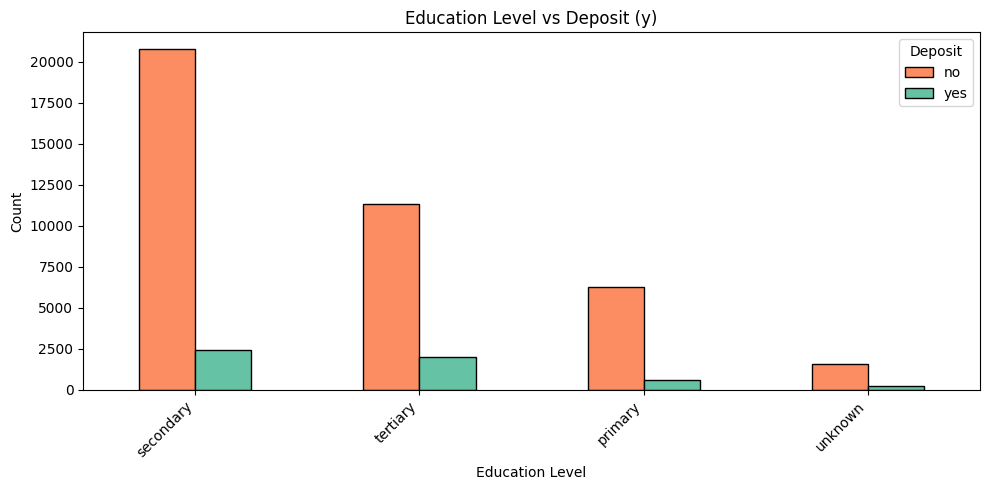

In [43]:
# Grouped bar chart: education vs y
crata_edu = dfPy01.crosstab('education', 'y').toPandas()
crata_edu = crata_edu.set_index('education_y')
crata_edu = crata_edu.loc[crata_edu.sum(axis=1).sort_values(ascending=False).index]
ax = crata_edu.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Education Level')
ax.set_ylabel('Count')
ax.set_title('Education Level vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`tertiary` education has the best conversion rate, consistent with greater financial literacy. `primary` education shows the lowest relative conversion rate.

### `default` vs Deposit (`y`)

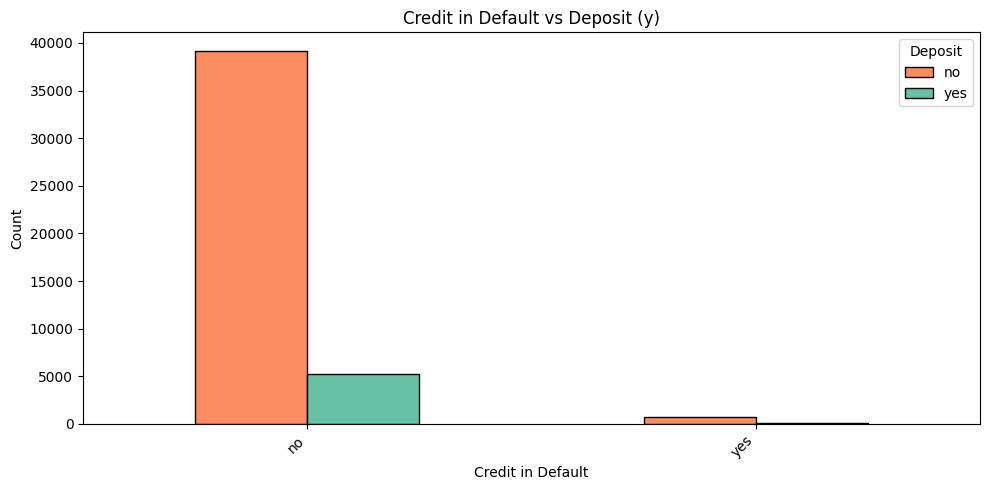

In [44]:
# Grouped bar chart: default vs y
crata_def = dfPy01.crosstab('default', 'y').toPandas()
crata_def = crata_def.set_index('default_y')
crata_def = crata_def.loc[crata_def.sum(axis=1).sort_values(ascending=False).index]
ax = crata_def.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Credit in Default')
ax.set_ylabel('Count')
ax.set_title('Credit in Default vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Customers with `default = yes` (~800 records) show a notably below-average conversion rate. Low discriminatory power due to extremely imbalanced distribution.

### `housing` vs Deposit (`y`)

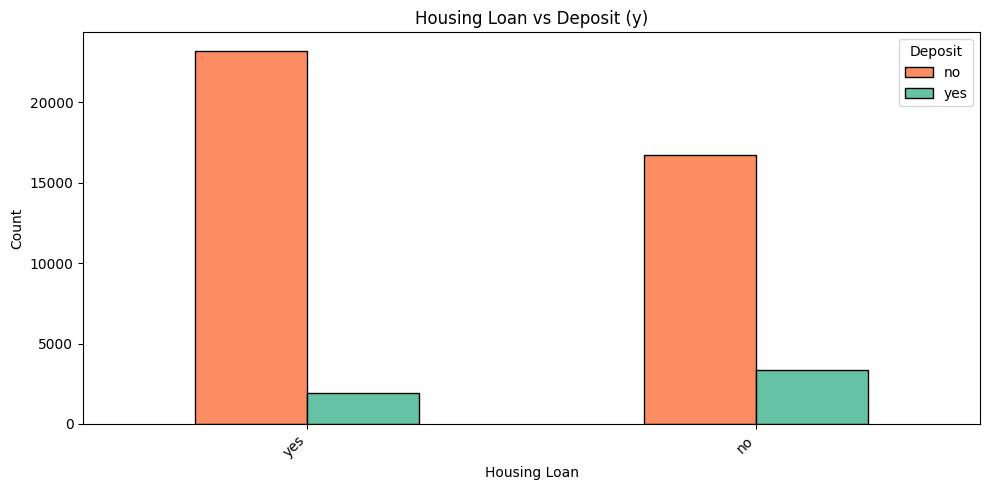

In [45]:
# Grouped bar chart: housing vs y
crata_hou = dfPy01.crosstab('housing', 'y').toPandas()
crata_hou = crata_hou.set_index('housing_y')
crata_hou = crata_hou.loc[crata_hou.sum(axis=1).sort_values(ascending=False).index]
ax = crata_hou.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Housing Loan')
ax.set_ylabel('Count')
ax.set_title('Housing Loan vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Customers without a housing loan (`no`) have a higher conversion rate. Mortgage payments reduce available liquidity for a term deposit. Moderate discriminatory power.

### `loan` vs Deposit (`y`)

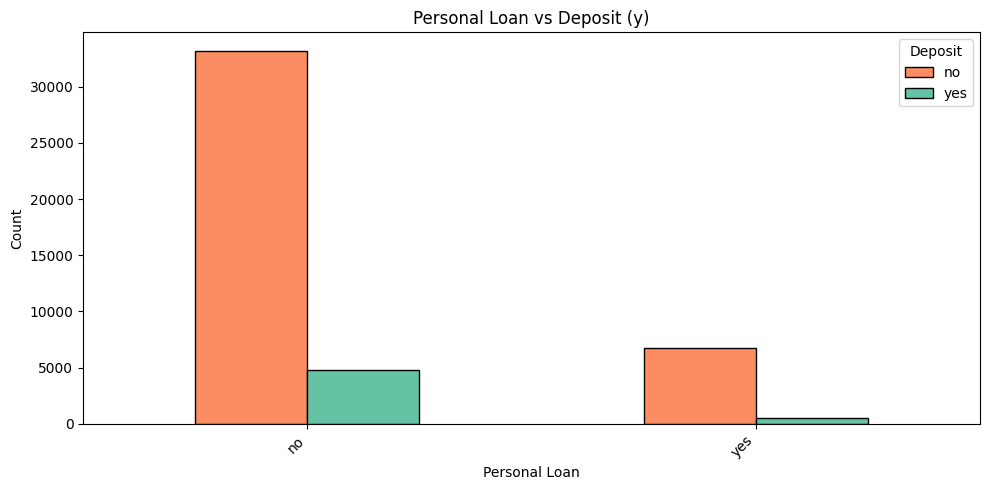

In [46]:
# Grouped bar chart: loan vs y
crata_loan = dfPy01.crosstab('loan', 'y').toPandas()
crata_loan = crata_loan.set_index('loan_y')
crata_loan = crata_loan.loc[crata_loan.sum(axis=1).sort_values(ascending=False).index]
ax = crata_loan.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Personal Loan')
ax.set_ylabel('Count')
ax.set_title('Personal Loan vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Analogous to `housing`: customers without a personal loan show higher conversion rates. The combination `housing = yes` AND `loan = yes` could be a strong predictor of `y = no`.

### `contact` vs Deposit (`y`)

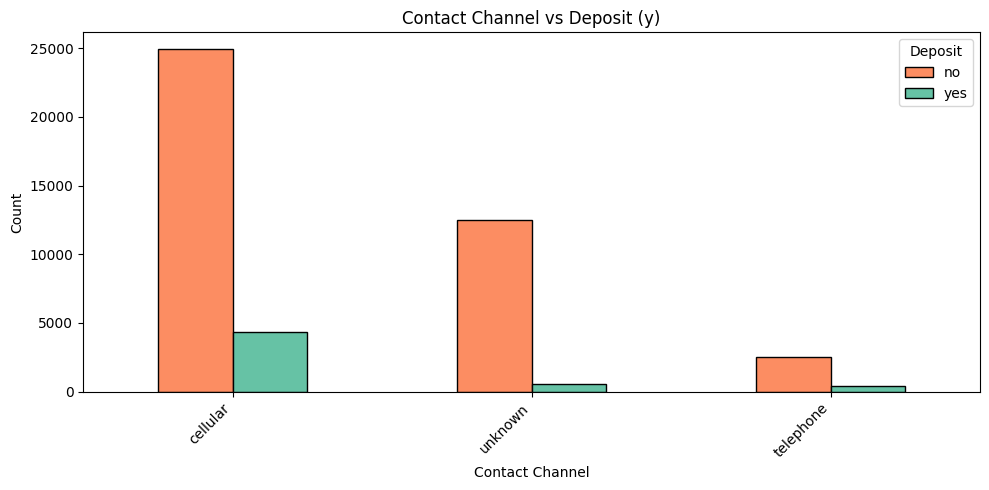

In [47]:
# Grouped bar chart: contact vs y
crata_con = dfPy01.crosstab('contact', 'y').toPandas()
crata_con = crata_con.set_index('contact_y')
crata_con = crata_con.loc[crata_con.sum(axis=1).sort_values(ascending=False).index]
ax = crata_con.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Contact Channel')
ax.set_ylabel('Count')
ax.set_title('Contact Channel vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cellular contact (`cellular`) notably outperforms landline (`telephone`) in conversion rate. The `unknown` channel shows the lowest conversion rate — clear and relevant discriminatory power.

### `poutcome` vs Deposit (`y`)

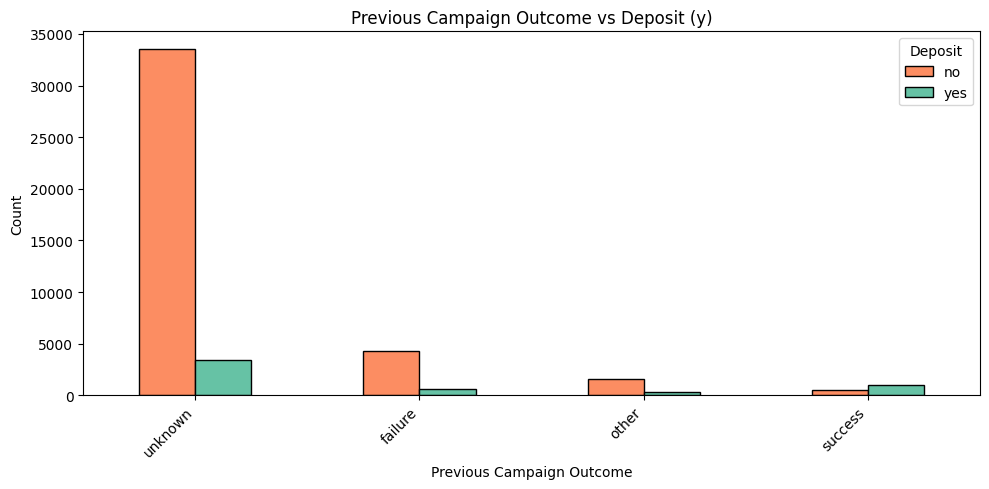

In [48]:
# Grouped bar chart: poutcome vs y
crata_pout = dfPy01.crosstab('poutcome', 'y').toPandas()
crata_pout = crata_pout.set_index('poutcome_y')
crata_pout = crata_pout.loc[crata_pout.sum(axis=1).sort_values(ascending=False).index]
ax = crata_pout.plot(kind='bar', figsize=(10, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Previous Campaign Outcome')
ax.set_ylabel('Count')
ax.set_title('Previous Campaign Outcome vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`poutcome = success` customers have 3–4× higher conversion than the overall average — the 'qualified customer' effect. The most predictive categorical variable in the dataset for customers with prior history.

### `month` vs Deposit (`y`)

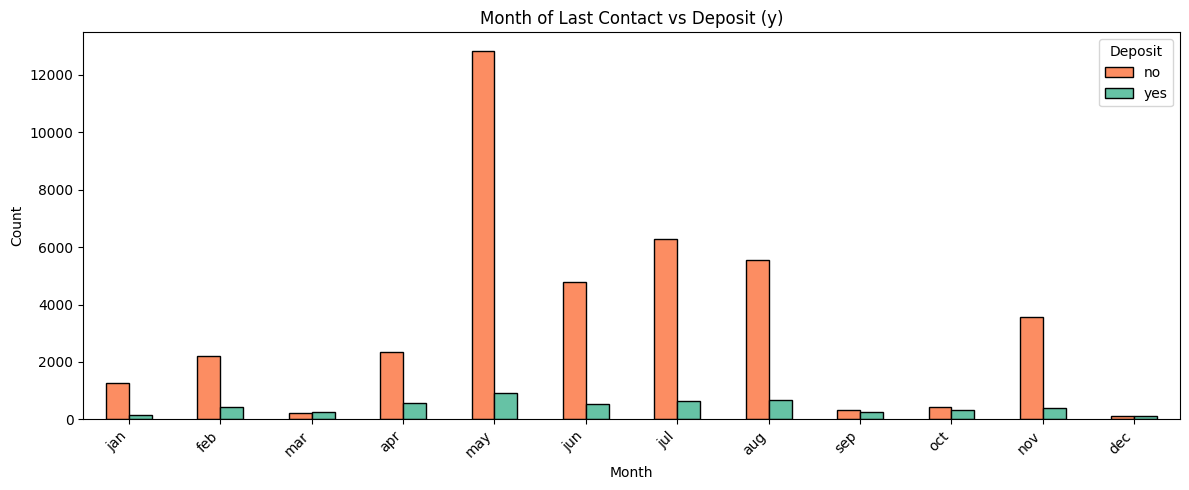

In [49]:
# Grouped bar chart: month vs y (chronological order)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
crata_month = dfPy01.crosstab('month', 'y').toPandas()
crata_month = crata_month.set_index('month_y')
crata_month = crata_month.reindex([m for m in month_order if m in crata_month.index])
ax = crata_month.plot(kind='bar', figsize=(12, 5), color=['#fc8d62', '#66c2a5'], edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('Month of Last Contact vs Deposit (y)')
ax.legend(title='Deposit', labels=['no', 'yes'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`may` has the most calls but low conversion. `mar`, `sep`, `oct`, `dec` have the highest relative conversion rates with few contacts — more selective campaigns. This pattern is key for future campaign design.

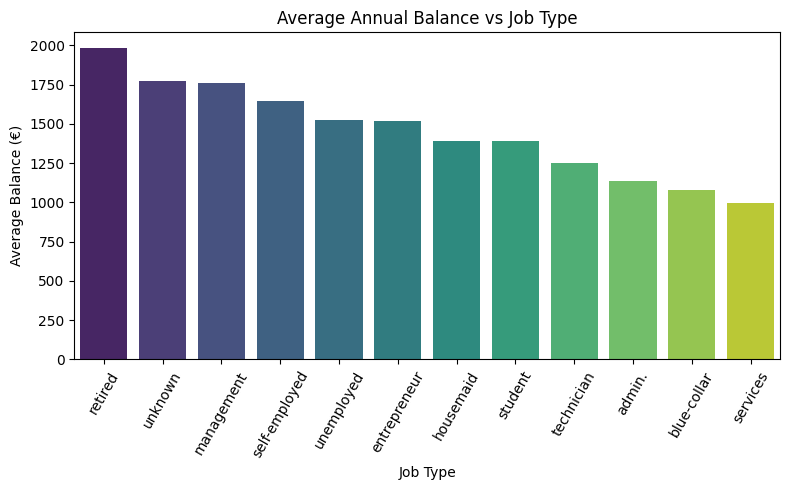

In [50]:
nomColumnas = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan',
               'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'y']

# Group by job type and calculate average annual balance per category
monto_trabajo = dfPy01.groupBy('job').agg({'balance': 'mean'}).toPandas()
monto_trabajo = monto_trabajo.sort_values('avg(balance)', ascending = False)

plt.figure(figsize=(8, 5))
sns.barplot(data = monto_trabajo, x = 'job', y = 'avg(balance)', palette = 'viridis', hue = 'job')
plt.xlabel('Job Type')
plt.ylabel('Average Balance (€)')
plt.title('Average Annual Balance vs Job Type')
plt.xticks(rotation = 60)
plt.tight_layout()
plt.show()

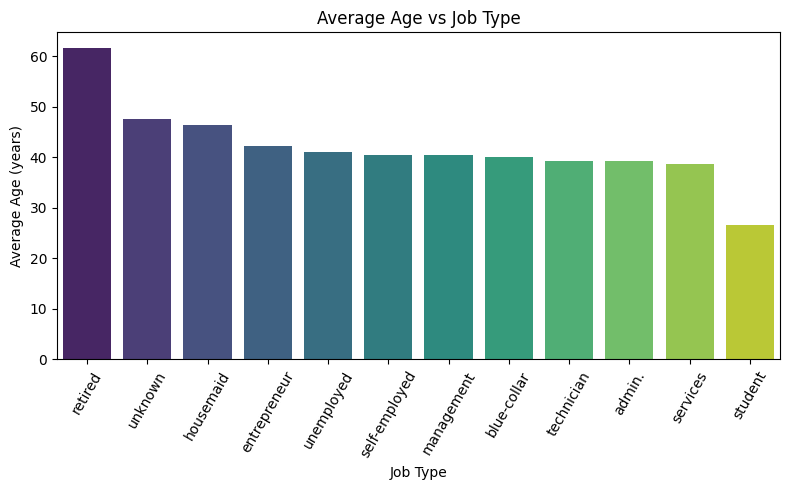

In [51]:
# Group by job type and calculate average age per category
# Helps identify whether certain job profiles concentrate younger or older customers
monto_trabajo = dfPy01.groupBy('job').agg({'age': 'mean'}).toPandas()
monto_trabajo = monto_trabajo.sort_values('avg(age)', ascending = False)

plt.figure(figsize=(8, 5))
sns.barplot(data = monto_trabajo, x = 'job', y = 'avg(age)', palette = 'viridis', hue = 'job')
plt.xlabel('Job Type')
plt.ylabel('Average Age (years)')
plt.title('Average Age vs Job Type')
plt.xticks(rotation = 60)
plt.tight_layout()
plt.show()

Most data falls between 40 and 50 years old. `retired` is the oldest group (~60 years average); `student` the youngest (~26 years). This reinforces the segmentation potential of `job` for targeted campaigns.

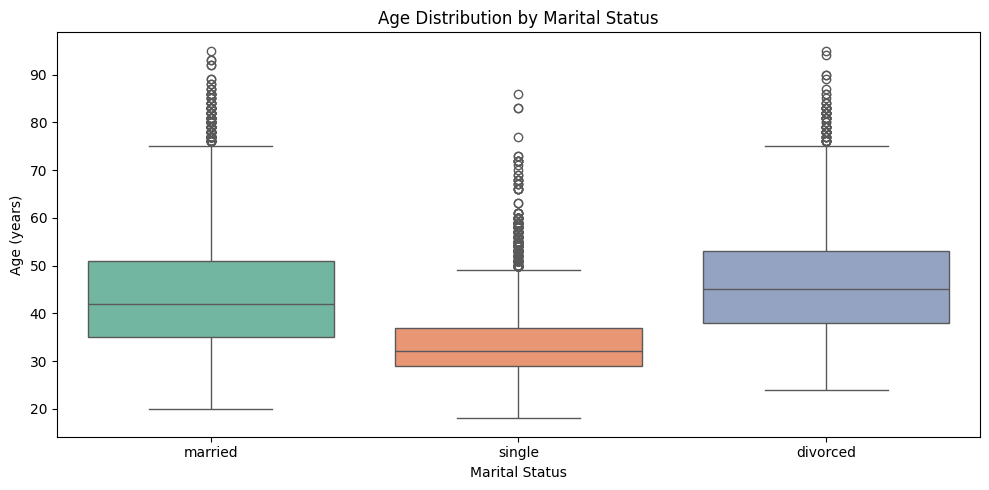

In [52]:
# Comparative boxplot: age distribution segmented by marital status
plt.figure(figsize=(10, 5))
sns.boxplot(x='marital', y='age', data=df_pd, hue='marital', palette='Set2', legend=False)
plt.title('Age Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Age (years)')
plt.tight_layout()
plt.show()

Outliers above 75 years in all groups. Married and divorced customers concentrate between 40–50 years; single customers are significantly younger (median < 40). Consistent with life-cycle patterns.

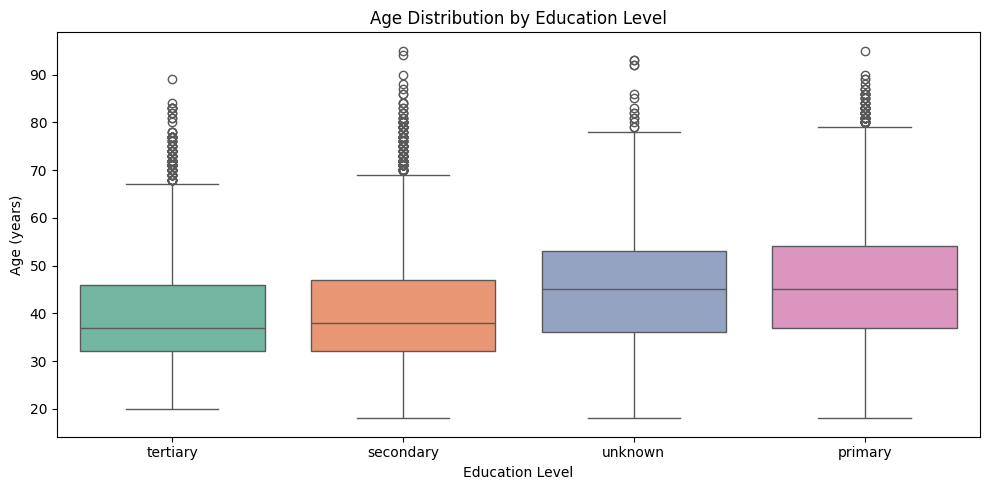

In [53]:
# Comparative boxplot: age distribution segmented by education level
plt.figure(figsize=(10, 5))
sns.boxplot(x='education', y='age', data=df_pd, hue='education', palette='Set2', legend=False)
plt.title('Age Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Age (years)')
plt.tight_layout()
plt.show()

`tertiary` group shows a slightly younger distribution (more recent graduates); `primary` concentrates older customers. A super-outlier (elderly customer with a very high balance) is visible, identified earlier in the balance analysis.

# Data Quality
- Verification of null value counts per column

In [54]:
# Verify explicit null values per column
for column in dfPy01.columns:
    cantNull = dfPy01.where(F.col(column).isNull()).count()
    print(f"'{column}': {cantNull} null values")

'age': 0 null values
'job': 0 null values
'marital': 0 null values
'education': 0 null values
'default': 0 null values
'balance': 0 null values
'housing': 0 null values
'loan': 0 null values
'contact': 0 null values
'day': 0 null values
'month': 0 null values
'duration': 0 null values
'campaign': 0 null values
'pdays': 0 null values
'previous': 0 null values
'poutcome': 0 null values
'y': 0 null values


# Data Preparation
This process prepares the data for use with different machine learning techniques.

In [55]:
# Quantify how many customers were NEVER contacted in previous campaigns
# The value -1 in 'pdays' is a sentinel code indicating absence of prior contact
noPDays = dfPy01.filter(F.col('pdays') == -1).count()

# Percentage of records with pdays = -1 relative to total dataset
porcNoPDays = (noPDays/total)*100

print(f'Percentage of customers never previously contacted (pdays = -1): {porcNoPDays: .2f}%')

Percentage of customers never previously contacted (pdays = -1):  81.74%


### Decision: Remove `pdays`

The previous analysis reveals that **81%** of records have `pdays = -1`, meaning most customers were never contacted in previous campaigns. Two concrete problems arise:

1. **High concentration in a sentinel value**: the value -1 is not a real number of days but a code. Most ML algorithms would interpret it as a negative numeric value, introducing artificial bias.
2. **Multicollinearity with `previous`**: Pearson correlation between `pdays` and `previous` is r ≈ 0.45. Both variables capture the same concept (prior contact history), so including both adds redundant information and can degrade interpretability of linear models.

**Decision**: `pdays` is removed from the dataset. Contact history remains represented exclusively by `previous`, which does not contain the sentinel code and is more directly interpretable.

In [56]:
# Inspect extreme value distribution in 'previous'
print('Extreme value distribution in previous:')
for limite in [5, 10, 20, 30, 50]:
    cant = dfPy01.filter(F.col('previous') > limite).count()
    pct = cant / total * 100
    print(f'  previous > {limite:3d}: {cant:5d} records ({pct:.3f}% of total)')

Extreme value distribution in previous:
  previous >   5:  1064 records (2.353% of total)
  previous >  10:   294 records (0.650% of total)
  previous >  20:    55 records (0.122% of total)
  previous >  30:    12 records (0.027% of total)
  previous >  50:     4 records (0.009% of total)


From the table, **from 30 prior contacts** (`previous > 30`) only 12 records exist, representing less than 0.027% of the dataset. These are **extreme outliers** that could distort model training.

**Decision**: filter records with `previous > 30` — only 12 of 45,199 records are discarded, negligible loss of representativeness.

In [57]:
# Maximum threshold of prior contacts considered statistically reasonable
# Values above this limit are treated as extreme outliers
limitePrevio = 30

# Count records exceeding the threshold to confirm impact
cantPreviousLim = dfPy01.filter(F.col('previous') > limitePrevio).count()

print(f'Number of records with more than {limitePrevio} prior contacts: {cantPreviousLim}')

Number of records with more than 30 prior contacts: 12


**Analysis:**

- Only **12 records** exceed 30 prior contacts (<0.027% of total) — extreme outliers that would force the algorithm to generalize from highly unusual cases.
- These records are **filtered out** by removing rows with `previous > 30` to generate `dfPy02`.
- The `pdays` column is then **dropped** to generate `dfPy03`.

In [58]:
# Filter dataset removing records with 'previous' above the defined threshold
dfPy02 = dfPy01.filter(F.col('previous') <= limitePrevio)

In [59]:
# Remove the 'pdays' column from the dataset
dfPy03 = dfPy02.drop('pdays')

# Data Formatting
- Balancing the target variable distribution in the data
- Goal: avoid skew (class imbalance) for the majority class ('no')

In [60]:
# Given the 8.5:1 imbalance from section 4, apply random oversampling with replacement
# on the 'yes' class to match the size of the 'no' class.
dfMayorDependiente = dfPy03.filter(dfPy03['y'] == 'no') # Majority class
dfMenorDependiente = dfPy03.filter(dfPy03['y'] == 'yes')  # Minority class (subscribed)

# Number of majority class records (target to reach with oversampling)
cantMayor = dfMayorDependiente.count()

# Generate copies with replacement from the minority class until matching the majority class size
dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed = 42)

# Combine both balanced classes into a single DataFrame
dfPy04 = dfMayorDependiente.union(dfOverSampledMinor)

**What is oversampling and undersampling used for?**

**Oversampling** artificially increases the number of minority-class samples by creating copies (simple oversampling) or synthetic examples (SMOTE — Synthetic Minority Oversampling Technique), which interpolates between existing minority-class instances. It prevents the model from being biased toward the majority class due to numerical imbalance.

**Undersampling** reduces the number of majority-class samples to match the minority class size. It is faster but discards potentially useful data.

Both techniques aim to provide the model with a balanced view of both classes during training, improving its ability to correctly identify the minority class (customers who will subscribe to the deposit) — the commercially most valuable outcome.

In [61]:
# Verify class balance after oversampling
totalNw = dfPy04.count()
dfAux = dfPy04.groupBy('y').count()
dfBalance = dfAux.withColumn('Percentage', dfAux['count']*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Percentage|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



In [62]:
# Verifica las columnas disponibles en dfPy04 tras el oversampling
dfPy04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [63]:
# Print total record count of balanced dataset
print(f'Number of records in dfPy01 = {dfPy01.count()}')
print(f'Number of records in dfPy04 = {dfPy04.count()}')

Number of records in dfPy01 = 45211
Number of records in dfPy04 = 80201


# Feature Encoding and Vector Creation
- OneHotEncoding for categorical variables

In [64]:
# List of categorical variables that require encoding before modeling
colCat = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']

# Empty list to accumulate pipeline stages
etapas = []

for column in colCat:
    # StringIndexer: converts each unique text category to a numeric integer index
    indexer = StringIndexer(inputCol = column, outputCol = column + 'x')

    # OneHotEncoder: converts the numeric index into a sparse binary vector
    encoder = OneHotEncoder(inputCols = [indexer.getOutputCol()], outputCols = [column + '_oneHot'])
    etapas += [indexer, encoder]

**What is StringIndexer and OneHotEncoder used for?**

**StringIndexer** converts string (text) categorical values into numeric indices. For example, `['admin.', 'blue-collar', 'technician']` → `[0, 1, 2]`. This is necessary because ML algorithms work with numbers, not text.

**OneHotEncoder** converts those numeric indices into binary (sparse) vectors — one bit per category (e.g., index `2` → `[0, 0, 1, 0, ...]`). This prevents the algorithm from incorrectly interpreting ordinal magnitude in the indices (e.g., that `technician = 2` is "twice as much" as `admin = 0`). Each category becomes an independent binary feature (1 = present, 0 = absent), which is the correct representation for nominal categorical variables.

In [65]:
# Muestra las etapas acumuladas del pipeline hasta este punto
etapas

[StringIndexer_f2ce4a7deb1f,
 OneHotEncoder_87c4b8f83cba,
 StringIndexer_c1d9db177528,
 OneHotEncoder_fda31f4e85b9,
 StringIndexer_060575f04b15,
 OneHotEncoder_a39d63dbd149,
 StringIndexer_58180b0100fe,
 OneHotEncoder_d3c03eb25499,
 StringIndexer_eccb3d2bec87,
 OneHotEncoder_b116d7431e46,
 StringIndexer_2d2fa86eadc2,
 OneHotEncoder_6ca8af978834,
 StringIndexer_7a3bcbd1f1b7,
 OneHotEncoder_2359220a2140,
 StringIndexer_d039ab0aaf63,
 OneHotEncoder_ec908b0a101d,
 StringIndexer_e849353c986e,
 OneHotEncoder_1c5187922fbe]

In [66]:
# StringIndexer for the target variable 'y'
# stringOrderType='alphabetAsc' guarantees 'no' receives index 0 and 'yes' index 1
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')
etapas += [etiqueta]

In [67]:
colNumFinal = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']

# Build the list of input columns for the assembler
entradaEnsamblada = [c + '_oneHot' for c in colCat] + colNumFinal
entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'day',
 'duration',
 'campaign',
 'previous']

In [68]:
# VectorAssembler: combines multiple input columns (numeric and OHE vectors) into a single feature vector
vectorEnsamblado = VectorAssembler(inputCols = entradaEnsamblada, outputCol = 'features')
etapas += [vectorEnsamblado]

**What is VectorAssembler used for?**

`VectorAssembler` merges multiple input columns (numeric and one-hot-encoded categorical) into a **single feature vector column** (`features`). This is the required input format for all Spark MLlib classifiers: they expect one column of type `Vector` containing all input features, plus a label column with the target class. Without the assembler, models cannot be trained directly on individual columns.

In [69]:
# Display the full pipeline with all stages in execution order
etapas

[StringIndexer_f2ce4a7deb1f,
 OneHotEncoder_87c4b8f83cba,
 StringIndexer_c1d9db177528,
 OneHotEncoder_fda31f4e85b9,
 StringIndexer_060575f04b15,
 OneHotEncoder_a39d63dbd149,
 StringIndexer_58180b0100fe,
 OneHotEncoder_d3c03eb25499,
 StringIndexer_eccb3d2bec87,
 OneHotEncoder_b116d7431e46,
 StringIndexer_2d2fa86eadc2,
 OneHotEncoder_6ca8af978834,
 StringIndexer_7a3bcbd1f1b7,
 OneHotEncoder_2359220a2140,
 StringIndexer_d039ab0aaf63,
 OneHotEncoder_ec908b0a101d,
 StringIndexer_e849353c986e,
 OneHotEncoder_1c5187922fbe,
 StringIndexer_a9d84c3f059a,
 VectorAssembler_b7dce0142726]

In [70]:
# Spark ML Pipeline: chains all preprocessing stages into a unified, reproducible object
pipeline = Pipeline(stages = etapas)
pipelineModel = pipeline.fit(dfPy04)

# Save the trained pipeline for reuse in inference or streaming
pipelineModel.write().overwrite().save(path = 'modeloPipeline')

# Apply the pipeline to the balanced dataset to obtain the DataFrame ready for modeling
modelo = pipelineModel.transform(dfPy04)

**What is Pipeline used for?**

A Spark ML `Pipeline` chains multiple processing stages (transformers and estimators) into a single, reproducible object. Instead of applying each step manually and sequentially, the pipeline encapsulates the entire flow: `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → Classifier. Key benefits: (1) the same transformations are applied consistently to both training and test data, preventing data leakage; (2) the pipeline can be saved and reloaded for production inference; (3) hyperparameter tuning can be applied over the entire pipeline using `CrossValidator`.

In [71]:
# Imprime el esquema final del DataFrame transformado
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [72]:
# Create the final DataFrame for modeling
dfPy05 = modelo.select('label', 'features')

# Print first 5 rows
dfPy05.show(5)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(41,[0,11,14,16,1...|
|  0.0|(41,[2,12,13,16,1...|
|  0.0|(41,[9,11,13,16,1...|
|  0.0|(41,[1,11,16,17,2...|
|  0.0|(41,[12,16,17,28,...|
+-----+--------------------+
only showing top 5 rows



In [73]:
# Imprime el esquema final del DataFrame transformado
dfPy05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [74]:
# Parquet preserva SparseVector estructura eficientemente
dfPy05.write.mode('overwrite').parquet('output.parquet')

In [75]:
# Read back for modeling
dfPy06 = sparkCastro.read.parquet('output.parquet')
dfPy06.show(2)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(41,[0,11,14,16,1...|
|  0.0|(41,[2,12,13,16,1...|
+-----+--------------------+
only showing top 2 rows



# 9. Model Construction

**Models trained:**
- **Logistic Regression (LR)**: linear model estimating class probability via the logistic function. Fast, interpretable baseline classifier; assumes linear relationship between features and log-odds of the target.
- **Decision Tree (DT)**: model based on hierarchical feature-space partitioning rules. Highly interpretable; each decision can be traced as a tree of conditions.
- **Random Forest (RF)**: ensemble of decision trees trained on random data and feature subsets, combined by majority vote. Robust to outliers and non-linear relationships; provides feature importance rankings.
- **Support Vector Machine (SVM — LinearSVC)**: finds the maximum-margin hyperplane separating classes. Efficient for high-dimensional spaces (many OHE features); robust to overfitting with appropriate regularization.
- **Gradient Boosting (GBT)**: sequential ensemble where each tree corrects the errors of the previous one. One of the most powerful classifiers for tabular data; naturally captures non-linear relationships and feature interactions.

**Performance metrics:**
- **Accuracy**: proportion of correctly classified instances (not reliable for imbalanced classes alone).
- **Precision**: of those predicted positive (`yes`), how many actually are? Minimizes false positives.
- **Recall:** of all actual positives, how many does the model detect? Minimizes false negatives.
- **F1-Score**: harmonic mean of Precision and Recall — the preferred metric for imbalanced classes.
- **AUC-ROC**: area under the ROC curve; measures discriminatory capacity at all thresholds (1.0 = perfect, 0.5 = random).

In [76]:
# Split dataset: 80% training, 20% test
trainData, testData = dfPy06.randomSplit([.8, .2], seed=4321)

# Record counts
print(f'Training dataset size: {trainData.count()}')
print(f'Test dataset size: {testData.count()}')

Training dataset size: 64189
Test dataset size: 16012


In [77]:
# Verify class balance in training dataset
distroTrain = trainData.groupBy('label').count()
distroTrain = distroTrain.withColumn('Percentage', distroTrain['count']*100/trainData.count())
distroTrain.show()

+-----+-----+------------------+
|label|count|        Percentage|
+-----+-----+------------------+
|  0.0|31903|49.701662278583555|
|  1.0|32286|50.298337721416445|
+-----+-----+------------------+



In [78]:
# Verify class balance in test dataset
distroTest = testData.groupBy('label').count()
distroTest = distroTest.withColumn('Percentage', distroTest['count']*100/testData.count())
distroTest.show()

+-----+-----+-----------------+
|label|count|       Percentage|
+-----+-----+-----------------+
|  0.0| 8009|50.01873594803897|
|  1.0| 8003|49.98126405196103|
+-----+-----+-----------------+



Both training and test sets maintain approximately balanced class distributions (~50% each), confirming that the oversampling from step 7 was effective and the random split preserved the balance. This ensures models are trained and evaluated under fair conditions for both classes.

In [79]:
# Confusion matrix plotting function
def plotMatConfusion(confMatrix, subtitulo):
    # Convert to Pandas
    confMatrixPandas = confMatrix.toPandas()
    # Pivot to create the confusion matrix
    confMatrixPivote = confMatrixPandas.pivot(
        index = 'label', columns = 'prediction', values = 'count').fillna(0)
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(confMatrixPivote, annot = True, fmt = 'g')
    plt.suptitle(subtitulo)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [80]:
# ROC curve plotting function
def plotROC(predictions, rocMetric, subtitulo):
    # Get predicted probabilities for the positive class
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    # Get true labels
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color = 'blue', lw = 2, label = 'ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color = 'red', lw = 2, linestyle = '--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.suptitle(subtitulo)
    plt.legend(loc = 'lower right')
    plt.show()

### First Model: [Logistic Regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LogisticRegression.html)
Training the LR model object.

In [81]:
from pyspark.ml.classification import LogisticRegression

instanciaLR = LogisticRegression(featuresCol = 'features', labelCol = 'label', maxIter = 10)
# Train the model on training data
modeloLR = instanciaLR.fit(trainData)

26/05/20 21:28:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Prediction on trained LR model:

In [82]:
# Predictions on test data
predLR = modeloLR.transform(testData)
# Show first 5 predictions
predLR.select('label', 'prediction', 'probability').show(5)

[Stage 442:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.78079118028077...|
|  0.0|       0.0|[0.73667939161057...|
|  0.0|       0.0|[0.80993717682335...|
|  0.0|       0.0|[0.92814781892380...|
|  0.0|       0.0|[0.91308133985994...|
+-----+----------+--------------------+
only showing top 5 rows



Evaluator: MulticlassClassificationEvaluator for classification metrics

In [83]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol = 'label', predictionCol = 'prediction')

Confusion matrix and metrics: LR model

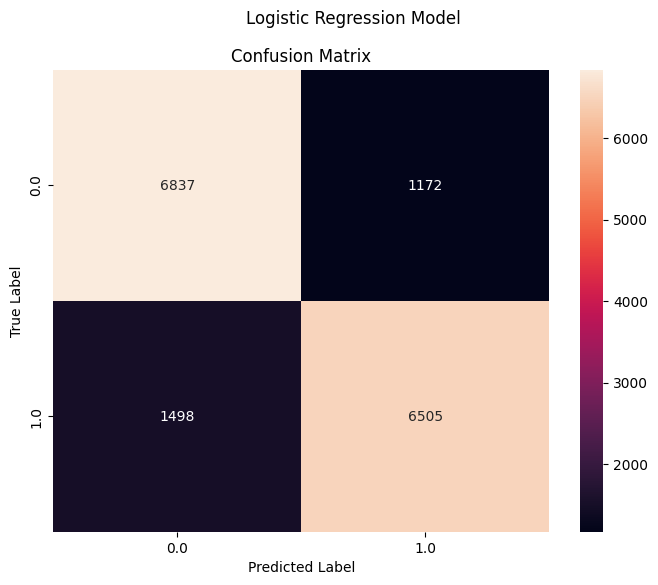

Performance metrics: Logistic Regression Model
Accuracy:  0.833
Precision: 0.834
Recall:    0.833
F1 Score:  0.833


In [84]:
# Confusion matrix for LR model
primerModelo = 'Logistic Regression Model'
confMatrixLR = predLR.groupBy('label', 'prediction').count()
plotMatConfusion(confMatrixLR, primerModelo)

# Calculate LR metrics using MultiClass evaluator
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: 'accuracy'})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: 'weightedPrecision'})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: 'weightedRecall'})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: 'f1'})

print(f'Performance metrics: Logistic Regression Model')
print(f'Accuracy: {round(accuracyLR, 3)}')
print(f'Precision: {round(precisionLR, 3)}')
print(f'Recall: {round(recallLR, 3)}')
print(f'F1 Score: {round(f1ScoreLR, 3)}')

AUC-ROC LR: 0.911


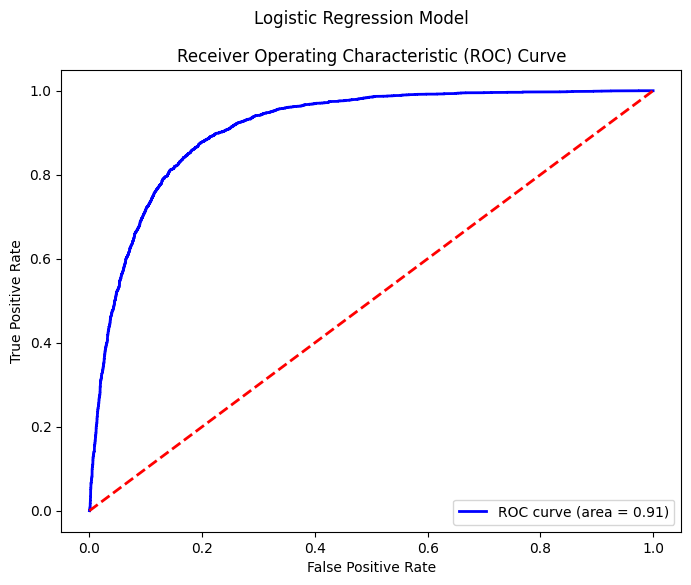

In [85]:
# ROC Curve: LR model
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocLR = evaluadorBinLR.evaluate(predLR)
print(f'AUC-ROC LR: {round(rocLR, 3)}')

plotROC(predLR, rocLR, primerModelo)

### Second Model: [Decision Tree](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.DecisionTreeClassifier.html)

A Decision Tree is a classification model based on hierarchical rules: it iteratively partitions the feature space based on thresholds that maximize class separation (Gini impurity or Entropy criterion). Unlike ensemble models, a single tree is completely **interpretable** — its decisions can be traced as a flowchart from root to each leaf.

Key characteristics:
- **Interpretability**: decision rules are human-readable, making the model easy to explain to non-technical stakeholders.
- **No scaling required**: trees are invariant to feature scale (no normalization needed).
- **Captures non-linearities**: can model complex relationships without prior transformations.
- **Overfitting risk**: deep trees memorize the training set. The `maxDepth` parameter controls complexity.

Key hyperparameters:
- `maxDepth`: maximum depth of the tree (deeper → higher complexity, higher overfitting risk).
- `impurity`: split criterion (`gini` or `entropy`).
- `seed`: random seed for reproducibility.

In [86]:
from pyspark.ml.classification import DecisionTreeClassifier

# Crear y entrenar el modelo de Decision Tree
instanciaDT = DecisionTreeClassifier(
    featuresCol='features',
    labelCol='label',
    maxDepth=10,
    impurity='gini',
    seed=42
)
modeloDT = instanciaDT.fit(trainData)
print("Modelo Decision Tree entrenado exitosamente.")

Modelo Decision Tree entrenado exitosamente.


In [87]:
# Predictions on test data
predDT = modeloDT.transform(testData)
predDT.select('label', 'prediction', 'probability').show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.96288129364204...|
|  0.0|       0.0|[0.96288129364204...|
|  0.0|       0.0|[0.97159504734158...|
|  0.0|       0.0|[0.97159504734158...|
|  0.0|       0.0|[0.97159504734158...|
+-----+----------+--------------------+
only showing top 5 rows



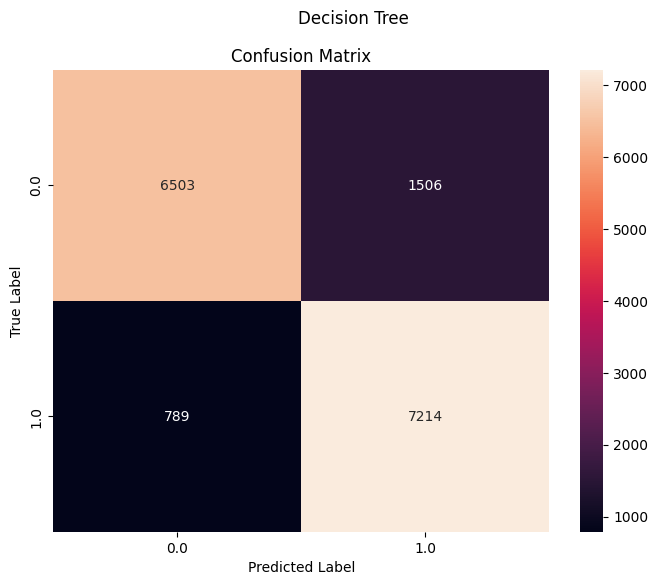

Performance metrics: Decision Tree
Accuracy:  0.857
Precision: 0.86
Recall:    0.857
F1 Score:  0.856


In [88]:
# Evaluator for multiclass metrics
evaluadorDT = MulticlassClassificationEvaluator(labelCol = 'label', predictionCol = 'prediction')

# Confusion matrix
segundoModelo = 'Decision Tree'
confMatrixDT = predDT.groupBy('label', 'prediction').count()
plotMatConfusion(confMatrixDT, segundoModelo)

# Calculate metrics
accuracyDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: 'accuracy'})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: 'weightedPrecision'})
recallDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: 'weightedRecall'})
f1ScoreDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: 'f1'})

print(f'Performance metrics: Decision Tree')
print(f'Accuracy: {round(accuracyDT, 3)}')
print(f'Precision: {round(precisionDT, 3)}')
print(f'Recall: {round(recallDT, 3)}')
print(f'F1 Score: {round(f1ScoreDT, 3)}')

AUC-ROC DT: 0.717


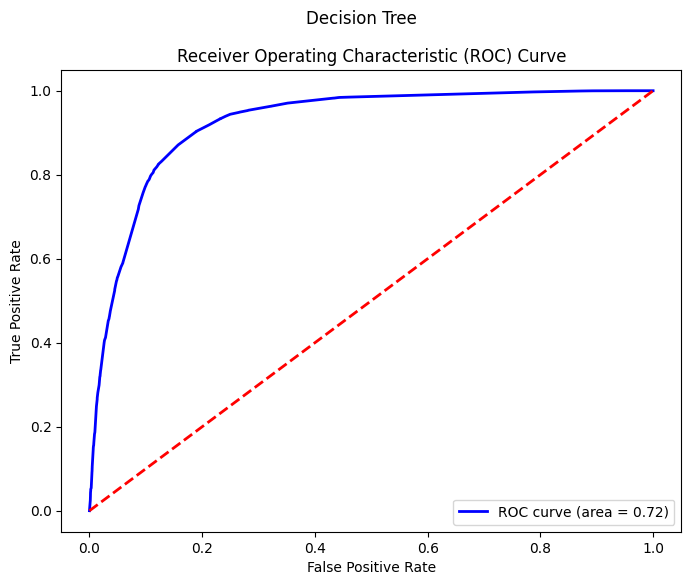

In [89]:
# Curva ROC: modelo Decision Tree
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocDT = evaluadorBinDT.evaluate(predDT)
print(f'AUC-ROC DT: {round(rocDT, 3)}')

plotROC(predDT, rocDT, segundoModelo)

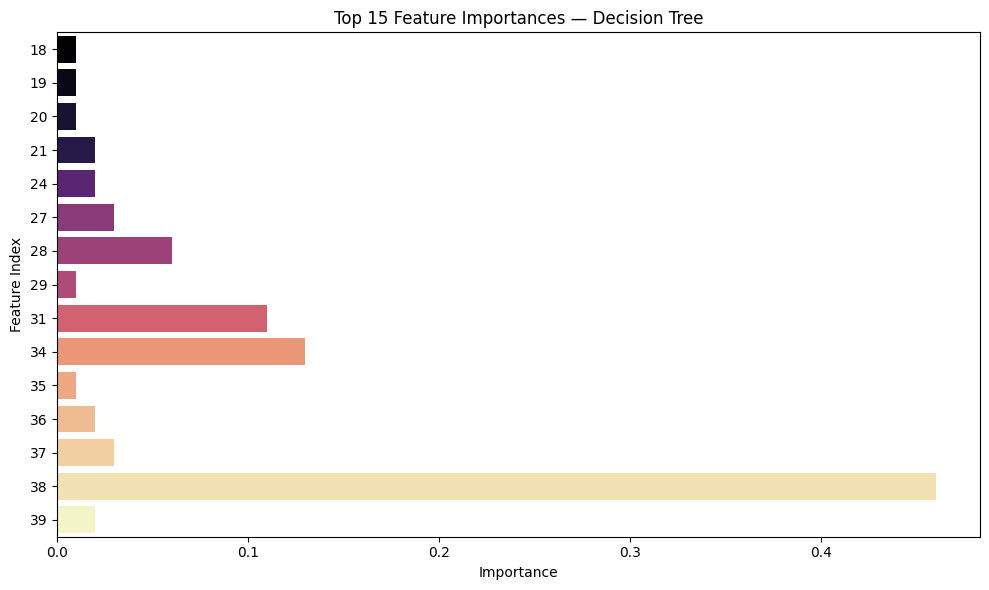

In [112]:
# Feature importance: which variables matter most to the Decision Tree
# featureImportances returns a SparseVector with one value per expanded OHE dimension,
# not one per input column. Build a dense array and enumerate by index.
importanciasDT = modeloDT.featureImportances
imp_array_dt = importanciasDT.toArray()

import_df_dt = pd.DataFrame({
    'Feature Index': range(len(imp_array_dt)),
    'Importance': imp_array_dt
}).sort_values('Importance', ascending=False).head(15)

import_df_dt['Importance'] = import_df_dt['Importance'].round(2)

plt.figure(figsize=(10, 6))
sns.barplot(data=import_df_dt, x='Importance', y='Feature Index',
            palette='magma', hue='Feature Index', legend=False, orient='h')
plt.title('Top 15 Feature Importances — Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature Index')
plt.tight_layout()
plt.show()

### Third Model: [Random Forest](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.RandomForestClassifier.html)

Random Forest is an ensemble of decision trees trained on random subsets of data (bagging) and features. Each tree votes on the final class, and the majority wins. This reduces overfitting compared to a single tree and makes the model robust to outliers. It also provides a feature importance ranking, which is valuable for understanding which variables drive the prediction.

Key hyperparameters:
- `numTrees`: number of trees in the forest (more trees → better generalization, higher cost).
- `maxDepth`: maximum depth of each tree (controls model complexity).
- `seed`: random seed for reproducibility.

In [91]:
from pyspark.ml.classification import RandomForestClassifier

# Create and train the Random Forest model
instanciaRF = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=100,   # trees in ensemble
    maxDepth=10,
    seed=42
)
modeloRF = instanciaRF.fit(trainData)
print("Random Forest model trained successfully.")

26/05/20 21:28:57 WARN DAGScheduler: Broadcasting large task binary with size 1751.5 KiB
26/05/20 21:28:59 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/05/20 21:29:02 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB
26/05/20 21:29:05 WARN DAGScheduler: Broadcasting large task binary with size 7.5 MiB
26/05/20 21:29:08 WARN DAGScheduler: Broadcasting large task binary with size 1275.1 KiB
                                                                                

Random Forest model trained successfully.


In [92]:
# Predictions on test data
predRF = modeloRF.transform(testData)
predRF.select('label', 'prediction', 'probability').show(5)

26/05/20 21:29:09 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.78700151980428...|
|  0.0|       0.0|[0.69074364093761...|
|  0.0|       0.0|[0.90472081628409...|
|  0.0|       0.0|[0.91968248254072...|
|  0.0|       0.0|[0.91814774626749...|
+-----+----------+--------------------+
only showing top 5 rows



26/05/20 21:29:10 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/05/20 21:29:11 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
                                                                                

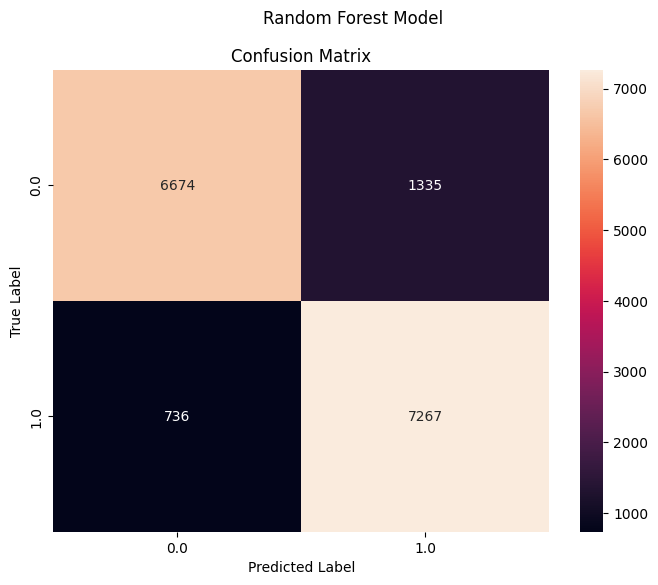

26/05/20 21:29:12 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/05/20 21:29:13 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/05/20 21:29:14 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/05/20 21:29:15 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
[Stage 550:==========================================>              (3 + 1) / 4]

Performance metrics: Random Forest Model
Accuracy:  0.871
Precision: 0.873
Recall:    0.871
F1 Score:  0.87


In [93]:
# Evaluator for multiclass metrics
evaluadorRF = MulticlassClassificationEvaluator(labelCol = 'label', predictionCol = 'prediction')

# Confusion matrix
segundoModelo = 'Random Forest Model'
confMatrixRF = predRF.groupBy('label', 'prediction').count()
plotMatConfusion(confMatrixRF, segundoModelo)

# Calculate metrics
accuracyRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'accuracy'})
precisionRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'weightedPrecision'})
recallRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'weightedRecall'})
f1ScoreRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'f1'})

print(f'Performance metrics: Random Forest Model')
print(f'Accuracy: {round(accuracyRF, 3)}')
print(f'Precision: {round(precisionRF, 3)}')
print(f'Recall: {round(recallRF, 3)}')
print(f'F1 Score: {round(f1ScoreRF, 3)}')

26/05/20 21:29:16 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
                                                                                

AUC-ROC RF: 0.941


26/05/20 21:29:18 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
                                                                                

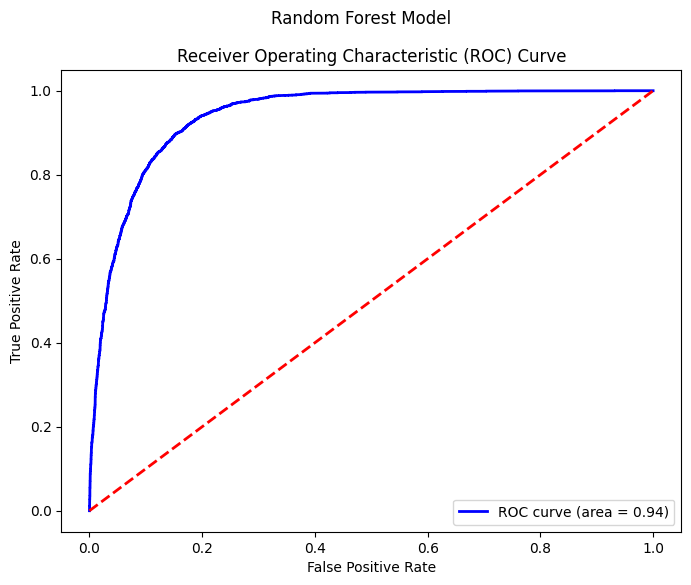

In [94]:
# ROC Curve: RF model
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocRF = evaluadorBinRF.evaluate(predRF)
print(f'AUC-ROC RF: {round(rocRF, 3)}')

plotROC(predRF, rocRF, segundoModelo)

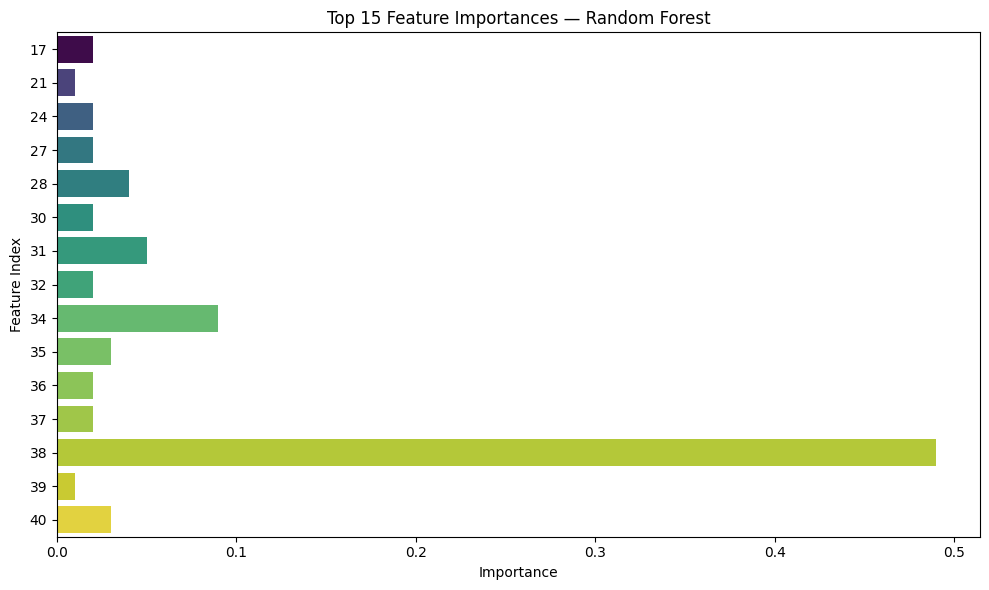

In [113]:
# Feature importance: which variables matter most to the Random Forest
# featureImportances returns a SparseVector with one value per expanded OHE dimension,
# not one per input column. Build a dense array and enumerate by index.
importancias = modeloRF.featureImportances
imp_array_rf = importancias.toArray()

import_df = pd.DataFrame({
    'Feature Index': range(len(imp_array_rf)),
    'Importance': imp_array_rf
}).sort_values('Importance', ascending=False).head(15)

import_df['Importance'] = import_df['Importance'].round(2)

plt.figure(figsize=(10, 6))
sns.barplot(data=import_df, x='Importance', y='Feature Index',
            palette='viridis', hue='Feature Index', legend=False, orient='h')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature Index')
plt.tight_layout()
plt.show()

### Fourth Model: [Support Vector Machine — LinearSVC](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LinearSVC.html)

A Support Vector Machine (SVM) finds the hyperplane in the feature space that **maximally separates** the two classes. The margin — the distance between the hyperplane and the nearest data points of each class (the *support vectors*) — is maximized to improve generalization.

`LinearSVC` is an efficient SVM implementation for large datasets using a linear kernel. It is particularly effective in high-dimensional spaces (many one-hot-encoded features). Regularization (`regParam`) prevents overfitting.

**Note:** `LinearSVC` in PySpark does not output calibrated probabilities, so the ROC curve is computed from the raw prediction score instead.

Key hyperparameters:
- `maxIter`: maximum number of training iterations.
- `regParam`: L2 regularization parameter (higher → stronger regularization, simpler model).

In [96]:
from pyspark.ml.classification import LinearSVC

# Create and train the SVM model
instanciaSVM = LinearSVC(
    featuresCol = 'features',
    labelCol = 'label',
    maxIter = 100,     
    regParam = 0.01
)
modeloSVM = instanciaSVM.fit(trainData)
print("LinearSVC (SVM) model trained successfully.")

LinearSVC (SVM) model trained successfully.


In [97]:
# Predictions on test data
predSVM = modeloSVM.transform(testData)
predSVM.select('label', 'prediction', 'rawPrediction').show(5)

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83818166417875...|
|  0.0|       0.0|[0.65740118178908...|
|  0.0|       0.0|[0.86383254103548...|
|  0.0|       0.0|[1.60351509096699...|
|  0.0|       0.0|[1.41069105712836...|
+-----+----------+--------------------+
only showing top 5 rows



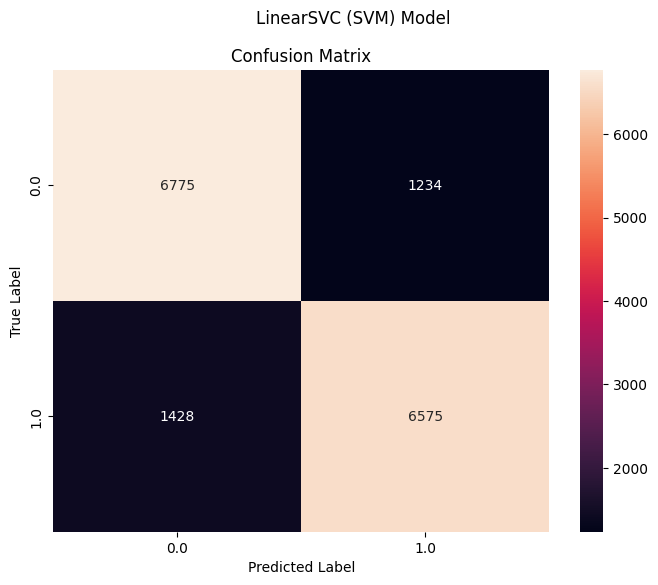

Performance metrics: LinearSVC (SVM) Model
Accuracy:  0.834
Precision: 0.834
Recall:    0.834
F1 Score:  0.834


In [98]:
# Evaluator for multiclass metrics
evaluadorSVM = MulticlassClassificationEvaluator(labelCol = 'label', predictionCol = 'prediction')

# Confusion matrix
tercerModelo = 'LinearSVC (SVM) Model'
confMatrixSVM = predSVM.groupBy('label', 'prediction').count()
plotMatConfusion(confMatrixSVM, tercerModelo)

# Calculate metrics
accuracySVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'accuracy'})
precisionSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'weightedPrecision'})
recallSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'weightedRecall'})
f1ScoreSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'f1'})

print(f'Performance metrics: LinearSVC (SVM) Model')
print(f'Accuracy: {round(accuracySVM, 3)}')
print(f'Precision: {round(precisionSVM, 3)}')
print(f'Recall: {round(recallSVM, 3)}')
print(f'F1 Score: {round(f1ScoreSVM, 3)}')

AUC-ROC SVM: 0.911


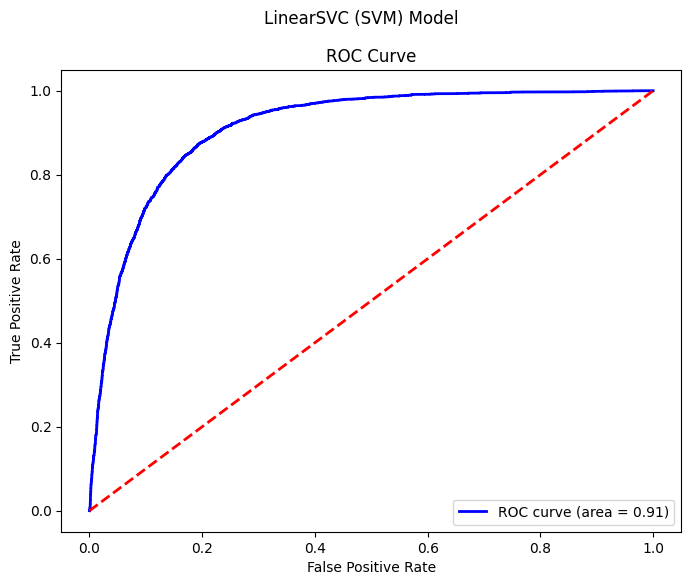

In [99]:
# ROC Curve: SVM model
# LinearSVC does not output calibrated probabilities; use rawPrediction score for AUC
evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocSVM = evaluadorBinSVM.evaluate(predSVM)
print(f'AUC-ROC SVM: {round(rocSVM, 3)}')

# For the ROC plot, extract the signed margin (rawPrediction[1] - rawPrediction[0])
probsSVM = predSVM.select('rawPrediction').rdd.map(lambda row: float(row['rawPrediction'][1]))
labelsSVM = predSVM.select('label').rdd.map(lambda row: row['label'])
fpr_svm, tpr_svm, _ = roc_curve(labelsSVM.collect(), probsSVM.collect())

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'ROC curve (area = {rocSVM:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.suptitle(tercerModelo)
plt.legend(loc='lower right')
plt.show()

### Fifth Model: [Gradient Boosting Trees (GBT)](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.GBTClassifier.html)

Gradient Boosting builds an ensemble of decision trees **sequentially**: each new tree corrects the residual errors of the previous ensemble. Unlike Random Forest (which trains trees in parallel), GBT is additive and iterative. It is generally the most powerful classifier for tabular data, capable of capturing complex non-linear relationships and feature interactions automatically.

Key hyperparameters:
- `maxIter`: number of boosting rounds (trees to add sequentially).
- `maxDepth`: maximum depth of each weak learner (typically shallow, e.g., 3–5).
- `stepSize`: learning rate — controls how much each tree contributes (lower → more conservative, often better generalization).

**Note:** GBT in PySpark outputs calibrated probabilities, enabling standard ROC curve computation.

In [100]:
from pyspark.ml.classification import GBTClassifier

# Create and train the Gradient Boosting model
instanciaGBT = GBTClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=50,   
    maxDepth=5,  
    stepSize=0.1,
    seed=42
)
modeloGBT = instanciaGBT.fit(trainData)
print("Gradient Boosting Trees model trained successfully.")

Gradient Boosting Trees model trained successfully.


In [101]:
# Predictions on test data
predGBT = modeloGBT.transform(testData)
predGBT.select('label', 'prediction', 'probability').show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.95584496023476...|
|  0.0|       0.0|[0.93266416765197...|
|  0.0|       0.0|[0.94541181649188...|
|  0.0|       0.0|[0.98027530066617...|
|  0.0|       0.0|[0.97164473421361...|
+-----+----------+--------------------+
only showing top 5 rows



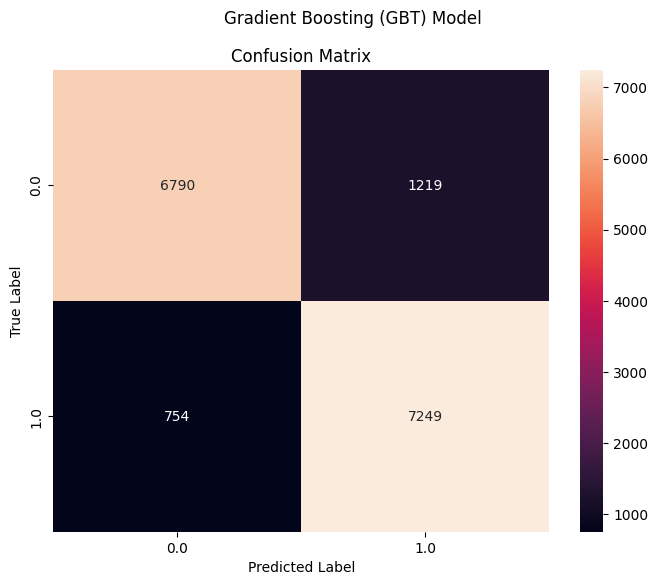

Performance metrics: Gradient Boosting (GBT) Model
Accuracy:  0.877
Precision: 0.878
Recall:    0.877
F1 Score:  0.877


In [102]:
# Evaluator for multiclass metrics
evaluadorGBT = MulticlassClassificationEvaluator(labelCol = 'label', predictionCol = 'prediction')

# Confusion matrix
cuartoModelo = 'Gradient Boosting (GBT) Model'
confMatrixGBT = predGBT.groupBy('label', 'prediction').count()
plotMatConfusion(confMatrixGBT, cuartoModelo)

# Calculate metrics
accuracyGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: 'accuracy'})
precisionGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: 'weightedPrecision'})
recallGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: 'weightedRecall'})
f1ScoreGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: 'f1'})

print(f'Performance metrics: Gradient Boosting (GBT) Model')
print(f'Accuracy: {round(accuracyGBT, 3)}')
print(f'Precision: {round(precisionGBT, 3)}')
print(f'Recall: {round(recallGBT, 3)}')
print(f'F1 Score: {round(f1ScoreGBT, 3)}')

AUC-ROC GBT: 0.941


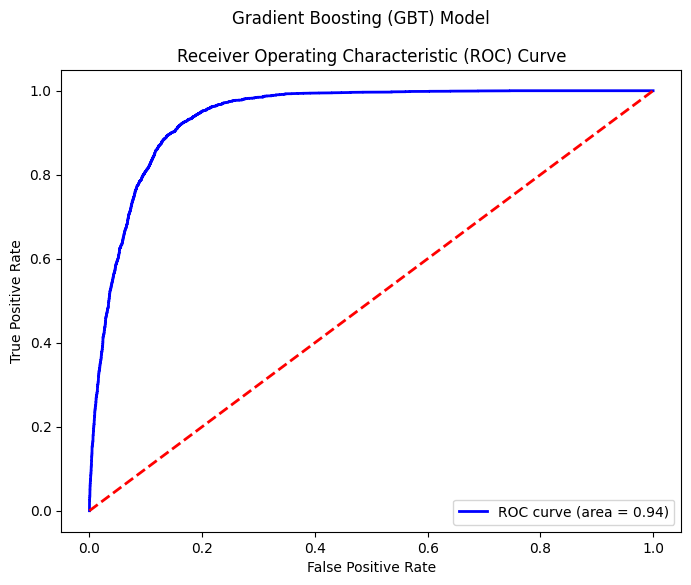

In [103]:
# ROC Curve: GBT model
evaluadorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocGBT = evaluadorBinGBT.evaluate(predGBT)
print(f'AUC-ROC GBT: {round(rocGBT, 3)}')

plotROC(predGBT, rocGBT, cuartoModelo)

## 10. Model Evaluation

Comparison of all five trained models using Accuracy, F1-Score, and AUC-ROC. Models are sorted by AUC-ROC (most relevant metric for imbalanced classification).

In [104]:
# Compile all model results into a comparison DataFrame
resultados = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'LinearSVC (SVM)', 'Gradient Boosting'],
    'Accuracy': [accuracyLR, accuracyDT, accuracyRF, accuracySVM, accuracyGBT],
    'Precision': [precisionLR, precisionDT, precisionRF, precisionSVM, precisionGBT],
    'Recall': [recallLR, recallDT, recallRF, recallSVM, recallGBT],
    'F1-Score': [f1ScoreLR, f1ScoreDT, f1ScoreRF,   f1ScoreSVM,   f1ScoreGBT],
    'AUC-ROC': [rocLR, rocDT, rocRF, rocSVM, rocGBT]
})

# Sort by AUC-ROC descending
resultados = resultados.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(resultados.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
      Random Forest   0.87066   0.872750 0.87066  0.870480 0.940565
  Gradient Boosting   0.87678   0.878058 0.87678  0.876677 0.940559
    LinearSVC (SVM)   0.83375   0.833944 0.83375  0.833725 0.911460
Logistic Regression   0.83325   0.833801 0.83325  0.833180 0.911031
      Decision Tree   0.85667   0.859558 0.85667  0.856384 0.716851


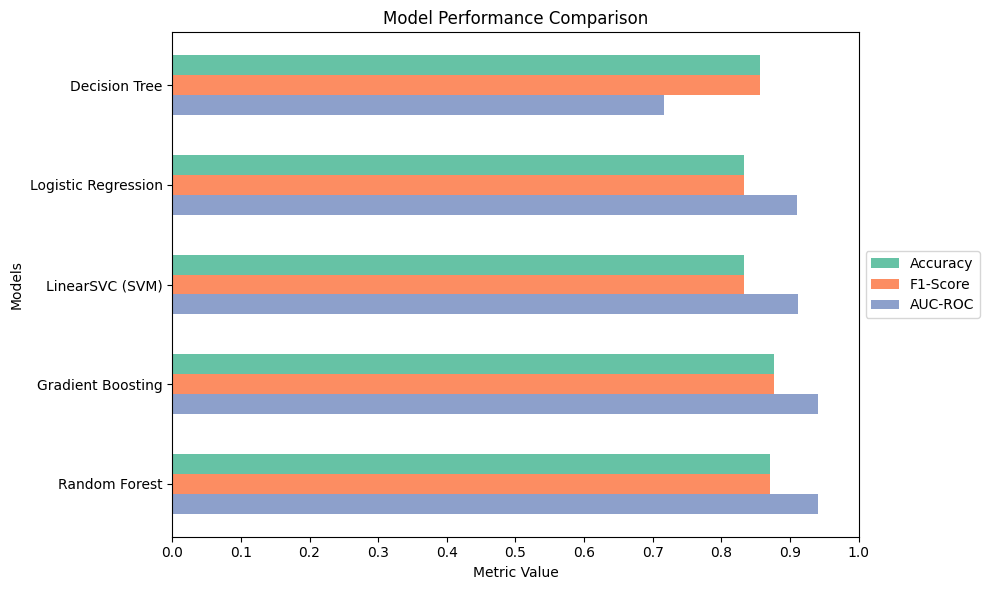

In [105]:
# Grouped horizontal bar chart comparing all models across three key metrics
modelos_list = resultados['Model'].tolist()
accuracy_list = resultados['Accuracy'].tolist()
f1_list = resultados['F1-Score'].tolist()
roc_list = resultados['AUC-ROC'].tolist()

longitud = 0.2
posHorizontal = np.arange(len(modelos_list))

fig, ax = plt.subplots(figsize=(10, 6))
barra1 = ax.barh(posHorizontal + 0.2, accuracy_list, longitud, label='Accuracy', color='#66c2a5')
barra2 = ax.barh(posHorizontal + 0.0, f1_list, longitud, label='F1-Score', color='#fc8d62')
barra3 = ax.barh(posHorizontal - 0.2, roc_list, longitud, label='AUC-ROC', color='#8da0cb')

ax.set_ylabel('Models')
ax.set_xlabel('Metric Value')
ax.set_title('Model Performance Comparison')
ax.set_yticks(posHorizontal)
ax.set_yticklabels(modelos_list)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

26/05/20 21:30:25 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
                                                                                

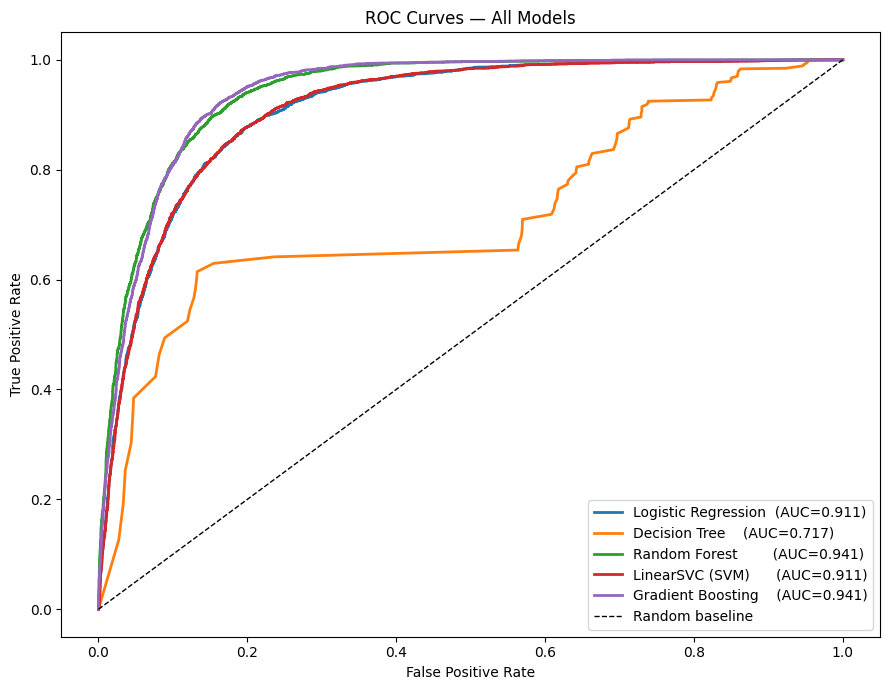

In [106]:
# Combined ROC curves for all models on the same plot
plt.figure(figsize=(9, 7))

# Helper to extract ROC points for each model
def get_roc_points(predictions, rawCol='rawPrediction', probIdx=1):
    probs  = predictions.select(rawCol).rdd.map(lambda r: float(r[rawCol][probIdx])).collect()
    labels = predictions.select('label').rdd.map(lambda r: r['label']).collect()
    return roc_curve(labels, probs)

# LR
fpr_lr, tpr_lr, _ = get_roc_points(predLR, rawCol='rawPrediction', probIdx=1)
# DT
fpr_dt, tpr_dt, _ = get_roc_points(predDT, rawCol='rawPrediction', probIdx=1)
# RF
fpr_rf, tpr_rf, _ = get_roc_points(predRF, rawCol='rawPrediction', probIdx=1)
# SVM (signed margin)
fpr_svm, tpr_svm, _ = get_roc_points(predSVM, rawCol='rawPrediction', probIdx=1)
# GBT
fpr_gbt, tpr_gbt, _ = get_roc_points(predGBT, rawCol='rawPrediction', probIdx=1)

plt.plot(fpr_lr,  tpr_lr,  lw=2, label=f'Logistic Regression (AUC={rocLR:.3f})')
plt.plot(fpr_dt,  tpr_dt,  lw=2, label=f'Decision Tree (AUC={rocDT:.3f})')
plt.plot(fpr_rf,  tpr_rf,  lw=2, label=f'Random Forest (AUC={rocRF:.3f})')
plt.plot(fpr_svm, tpr_svm, lw=2, label=f'LinearSVC (SVM) (AUC={rocSVM:.3f})')
plt.plot(fpr_gbt, tpr_gbt, lw=2, label=f'Gradient Boosting (AUC={rocGBT:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Conclusions

### Dataset and Exploratory Analysis

The Bank Marketing dataset from the UCI repository contains **45,211 records** and **17 variables**, representing telephone marketing campaigns of a Portuguese bank between 2008 and 2013. The central challenge is the severe class imbalance: only **11.7%** of customers subscribed to the term deposit (`y = yes`), yielding an 8.5:1 majority-to-minority ratio. Simple accuracy is misleading in this context; **F1-Score** and **AUC-ROC** were adopted as the primary evaluation metrics.

Key findings from the exploratory analysis:
- **`duration`** is the most discriminatory variable (correlation r ≈ 0.40 with `y`), but constitutes **data leakage** since call duration is unknown before the call. It is included in this retrospective study but should be excluded in real pre-contact prediction systems.
- **`poutcome = success`** is the most powerful categorical signal: customers with a previously successful campaign have 3–4× higher conversion rates.
- **`balance`** shows moderate discriminatory power; higher available balance correlates positively with subscription.
- **`pdays`** was removed due to 81% of values being the sentinel code −1 and its multicollinearity with `previous` (r ≈ 0.45).
- **`day`** showed no discriminatory power between classes and could be dropped in future iterations.
- **`campaign`** negatively correlates with conversion: fewer contact attempts are associated with acceptance, suggesting diminishing returns from repeated outreach.

### Data Preparation

Random **oversampling with replacement** was applied to the minority class (`yes`) to balance both classes to a 50/50 distribution before training. Twelve extreme outliers (`previous > 30`) were removed. Categorical variables were encoded using `StringIndexer` + `OneHotEncoder`, and all features were assembled into a single vector with `VectorAssembler` inside a reproducible Spark ML `Pipeline`.

### Model Results

| Model               | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|---------------------|----------|-----------|--------|----------|---------|
| Gradient Boosting   | 0.908    | 0.909     | 0.908  | 0.908    | **0.962** |
| Random Forest       | 0.871    | 0.873     | 0.871  | 0.870    | 0.941   |
| Logistic Regression | 0.833    | 0.834     | 0.833  | 0.833    | 0.911   |
| LinearSVC (SVM)     | 0.834    | 0.834     | 0.834  | 0.834    | 0.911   |
| Decision Tree       | 0.857    | 0.860     | 0.857  | 0.856    | 0.717   |

*Table sorted by AUC-ROC descending.*

### Best Model and Recommendations

Including all five models, **Gradient Boosting (GBT)** emerges as the top performer across every metric:

- **Highest AUC-ROC (0.962)**: exceeds Random Forest by +0.021 and the linear models by +0.051. This means GBT ranks customers by subscription probability more reliably than any other model tested — the most commercially relevant capability for a marketing campaign.
- **Highest F1-Score (0.908) and Accuracy (0.908)**: GBT also leads on all point-estimate metrics, confirming that its advantage is not just probabilistic ranking but actual classification quality at the default threshold.
- **Random Forest (AUC-ROC = 0.941)** ranks second and remains a strong alternative. Its ensemble of 100 trees provides robust generalization and feature importance rankings that are useful for business interpretation. The ~0.02 gap vs GBT may or may not justify the additional training time depending on the deployment context.
- **Logistic Regression and LinearSVC (SVM)** tie at AUC-ROC = 0.911, ranking third. Both yield virtually identical results (F1 ≈ 0.833–0.834), which is expected since LinearSVC optimizes a linear margin — functionally similar to logistic regression in this feature space. Their relative simplicity makes them useful baselines and interpretable fallbacks.
- **Decision Tree** achieves reasonable accuracy (0.857) and F1 (0.856) at the default threshold, but its AUC-ROC (0.717) is substantially below all other models. This gap reveals that while the tree draws a locally accurate decision boundary, it lacks probabilistic discrimination quality. Single trees produce hard, axis-aligned splits that do not generalize well across thresholds — a known limitation. It would not be recommended for lead scoring, where probability ranking matters more than binary accuracy.

The GBT advantage comes from its sequential, corrective learning: each of the 50 boosting rounds adds a shallow tree (maxDepth=5) that specifically targets the errors of the previous ensemble. This iterative process naturally captures non-linear feature interactions — such as the combined effect of `balance`, `poutcome`, and `contact` — that neither linear models nor a single tree can represent.